# GR00T N1.7 — UR10e Cup — standalone P50 candidate — Modal L40S

This notebook is fully independent of previously trained baseline artifacts.
It downloads the original GR00T N1.7-3B checkpoint, creates an exact P50 CKA
manifest, performs full retained-module recovery and evaluates only P50.

Recommended Modal profile: **1x L40S, 8 CPU cores, 48 GiB RAM**, Volume
`gr00t-ur10e-cup` mounted at `/mnt/gr00t-experiment`.


## Required execution order

1. `setup`: validate the Modal L40S/Volume, install GR00T, download the pinned
   original GR00T checkpoint, convert LeRobot v3 and create the train-only view.
2. `prepare_cka`: capture hidden states from the original checkpoint and create
   the exact P50 manifest (16/32 Action-DiT, 8/16 language, 4/4 VLSA).
3. `cka_recovery`: recover only the P50 candidate from the original checkpoint
   for the fixed 6000-step recovery target.
4. `evaluate`: benchmark only P50 on held-out episodes, including raw error,
   eight diffusion seeds, per-channel metrics and aligned prediction plots.
5. `report`: validate candidate-only evidence and create ZIP + SHA-256.

This notebook never loads, trains, benchmarks or archives a baseline model.
Baseline evidence from the completed P25 experiment must be compared later in a
separate reference-comparison notebook.


In [18]:
from pathlib import Path
import os

# ========================= USER CONFIGURATION =========================
# setup | prepare_cka | cka_recovery | evaluate | report
WORKFLOW_PHASE = "report"

# This standalone candidate is fixed to the 6000-step recovery budget.
FINAL_RECOVERY_STEP = 6000

# Keep the active recovery target identical to the final budget.
RECOVERY_TARGET_STEPS = 6000

# Explicit requested retained depths:
#   language: 8/16  -> 50% pruned
#   Action-DiT: 16/32 -> 50% pruned
#   VLSA: 4/4 -> unpruned, matching the established P25/P37/P50/P75 comparison contract
BACKBONE_LANGUAGE_PRUNE_RATIO = 0.50
ACTION_DIT_PRUNE_RATIO = 0.50
VL_SELF_ATTENTION_PRUNE_RATIO = 0.0
EXPECTED_ORIGINAL_DEPTHS = {
    "backbone_language": 16,
    "action_dit": 32,
    "vl_self_attention": 4,
}
EXPECTED_KEPT_DEPTHS = {
    "backbone_language": 8,
    "action_dit": 16,
    "vl_self_attention": 4,
}

REPO_URL = "https://github.com/nmduc9624/Isaac-GR00T.git"
BRANCH = "cka-n1d7-recovery"
REPO_COMMIT = "bcea4058cd6a0d5b2f8326279f7fb70890ccecf4"
MODEL_REPO = "nvidia/GR00T-N1.7-3B"
MODEL_REVISION = "2fc962b973bccdd5d8ce4f67cc63b264d6886495"
DATASET_REPO = "khanhnd61/ur10e-cup"
DATASET_REVISION = "12bbeaad3995e84cf43b99adecb0a8bc216cedbf"
EMBODIMENT_TAG = "NEW_EMBODIMENT"

# Standalone candidate: no pre-trained task baseline is required.

# Single-L40S resource contract. This is full retained-module recovery,
# not LoRA, but it is intentionally smaller than the 8-GPU reference recipe.
NUM_GPUS = 1
GLOBAL_BATCH = 1
GRADIENT_ACCUMULATION = 8
DATALOADER_NUM_WORKERS = 4
LEARNING_RATE = 1e-4
WARMUP_RATIO = 0.05
WEIGHT_DECAY = 1e-5
STATE_DROPOUT_PROB = 0.2
SAVE_STEPS = 250
SAVE_TOTAL_LIMIT = 1
assert FINAL_RECOVERY_STEP == RECOVERY_TARGET_STEPS == 6000
assert RECOVERY_TARGET_STEPS % SAVE_STEPS == 0
SHARD_SIZE = 1024
NUM_SHARDS_PER_EPOCH = 100_000
EPISODE_SAMPLING_RATE = 0.1
COLOR_JITTER = [
    "brightness", "0.3", "contrast", "0.4",
    "saturation", "0.5", "hue", "0.08",
]
USE_PERCENTILES = True
TUNE_LLM = False
TUNE_VISUAL = False
TUNE_PROJECTOR = True
TUNE_DIFFUSION_MODEL = True
TUNE_VLLN = True
USE_WANDB = False
SEED = 42

# One-L40S hardware contract. Modal may expose CPU reservations as logical
# cores; the checks intentionally validate only the safe execution minimum.
STRICT_HARDWARE_PREFLIGHT = True
MIN_LOGICAL_CPUS = 8
MIN_SYSTEM_RAM_GIB = 46
MIN_GPU_COUNT = 1
MIN_GPU_VRAM_GIB = 44
REQUIRE_L40S = True

# Deterministic leakage-controlled episode contract.
TRAIN_EPISODES = list(range(0, 65))
VALIDATION_EPISODES = list(range(65, 73))
TEST_EPISODES = list(range(73, 81))
CALIBRATION_TRAJECTORIES = list(range(0, 64, 4))
SAMPLES_PER_CALIBRATION_TRAJECTORY = 16
SAMPLES_PER_VALIDATION_TRAJECTORY = 32
SAMPLE_STRIDE = 2
DENOISING_STEPS = 16
# Seed 42 is the deploy-like raw run; the remaining paired seeds estimate
# diffusion sampling variance without smoothing or altering ground truth.
EVAL_REPEAT_SEEDS = [42, 43, 44, 45, 46, 47, 48, 49]

RUN_CKA = WORKFLOW_PHASE == "prepare_cka"
RUN_CKA_RECOVERY = WORKFLOW_PHASE == "cka_recovery"
RUN_EVALUATION = WORKFLOW_PHASE == "evaluate"
RUN_REPORT = WORKFLOW_PHASE == "report"

assert WORKFLOW_PHASE in {
    "setup", "prepare_cka", "cka_recovery", "evaluate", "report",
}
assert isinstance(FINAL_RECOVERY_STEP, int) and FINAL_RECOVERY_STEP > 0
assert isinstance(RECOVERY_TARGET_STEPS, int)
assert 1 <= RECOVERY_TARGET_STEPS <= FINAL_RECOVERY_STEP
assert NUM_GPUS == 1 and GLOBAL_BATCH == 1
assert GRADIENT_ACCUMULATION == 8
assert DATALOADER_NUM_WORKERS == 4
assert len(EVAL_REPEAT_SEEDS) >= 2 and EVAL_REPEAT_SEEDS[0] == SEED
assert len(set(EVAL_REPEAT_SEEDS)) == len(EVAL_REPEAT_SEEDS)
assert LEARNING_RATE == 1e-4 and WARMUP_RATIO == 0.05 and WEIGHT_DECAY == 1e-5
assert TUNE_PROJECTOR and TUNE_DIFFUSION_MODEL and TUNE_VLLN
assert not TUNE_LLM and not TUNE_VISUAL
assert TRAIN_EPISODES == list(range(65))
assert set(TRAIN_EPISODES).isdisjoint(VALIDATION_EPISODES)
assert set(TRAIN_EPISODES).isdisjoint(TEST_EPISODES)
assert set(VALIDATION_EPISODES).isdisjoint(TEST_EPISODES)

PLATFORM = "modal"
MODAL_VOLUME_NAME = "gr00t-ur10e-cup"
PERSIST_ROOT = Path("/mnt/gr00t-experiment")
RUNTIME_ROOT = Path("/root/gr00t-runtime")
CACHE_ROOT = RUNTIME_ROOT / "cache"
HF_HOME_ROOT = RUNTIME_ROOT / "hf-home"
assert PERSIST_ROOT.is_dir(), (
    "Attach Modal Volume gr00t-ur10e-cup at /mnt/gr00t-experiment before running."
)

REPO_DIR = RUNTIME_ROOT / "Isaac-GR00T"
UV_PROJECT_ENVIRONMENT = RUNTIME_ROOT / "isaac-gr00t-venv"
UV_CACHE_DIR = RUNTIME_ROOT / "uv-cache"
HF_HOME = HF_HOME_ROOT
CHECKPOINT_ROOT = PERSIST_ROOT / "cache" / "checkpoints"
MODEL_PATH = CHECKPOINT_ROOT / "GR00T-N1.7-3B"
DATASET_ROOT = PERSIST_ROOT / "cache" / "datasets"
DATASET_PREP_ROOT = DATASET_ROOT / "ur10e_cup_lerobot"
FULL_DATASET = DATASET_PREP_ROOT / "khanhnd61" / "ur10e-cup"
TRAIN_DATASET = DATASET_ROOT / "ur10e-cup-train65"
assert CHECKPOINT_ROOT.is_relative_to(PERSIST_ROOT)
assert DATASET_ROOT.is_relative_to(PERSIST_ROOT)

STEP_TAG = f"{FINAL_RECOVERY_STEP}steps"
VARIANT_TAG = "cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate"
EXPERIMENT_ROOT = PERSIST_ROOT / "experiments" / f"gr00t_n1d7_ur10e_cup_{VARIANT_TAG}_{STEP_TAG}"
OUTPUT_ROOT = EXPERIMENT_ROOT / "results"
# Candidate checkpoints are persistent and resumable on Modal Volume.
TRAIN_OUTPUT_ROOT = PERSIST_ROOT / "training" / EXPERIMENT_ROOT.name
CKA_OUTPUT = TRAIN_OUTPUT_ROOT / f"cka_p50_standalone_full_recovery_l40s_{STEP_TAG}"
SOURCE_CALIBRATION_DIR = OUTPUT_ROOT / "source_calibration"
ANALYSIS_DIR = OUTPUT_ROOT / "source_cka_analysis"
PRUNING_MANIFEST = ANALYSIS_DIR / "pruning_manifest.json"
EVAL_CKA = OUTPUT_ROOT / "eval_cka_p50_keep16dit_keep8lang"
CANDIDATE_ANALYSIS = OUTPUT_ROOT / "candidate_analysis"
HEATMAP_ROOT = OUTPUT_ROOT / "heatmap_comparison"
ARCHIVE_ROOT = PERSIST_ROOT / "archives" / f"ur10e_cup_{VARIANT_TAG}_{STEP_TAG}"
FINAL_ZIP = ARCHIVE_ROOT / f"gr00t_n1d7_ur10e_cup_{VARIANT_TAG}_{STEP_TAG}_candidate_only_results.zip"

for path in [
    RUNTIME_ROOT, OUTPUT_ROOT, TRAIN_OUTPUT_ROOT, CHECKPOINT_ROOT, DATASET_ROOT,
    SOURCE_CALIBRATION_DIR, ANALYSIS_DIR, EVAL_CKA,
    CANDIDATE_ANALYSIS, HEATMAP_ROOT, ARCHIVE_ROOT,
]:
    path.mkdir(parents=True, exist_ok=True)

os.environ["UV_PROJECT_ENVIRONMENT"] = str(UV_PROJECT_ENVIRONMENT)
os.environ["UV_CACHE_DIR"] = str(UV_CACHE_DIR)
os.environ["HF_HOME"] = str(HF_HOME)
os.environ["HF_HUB_CACHE"] = str(HF_HOME / "hub")
os.environ.pop("TRANSFORMERS_CACHE", None)
os.environ.pop("GR00T_LOW_VRAM_T4", None)
os.environ["GR00T_ACTIVATION_CHECKPOINTING"] = "1"
for key in list(os.environ):
    if key.startswith("GR00T_ACTION_DIT_LORA_"):
        os.environ.pop(key, None)
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"
os.environ["MPLBACKEND"] = "Agg"
os.environ["NO_ALBUMENTATIONS_UPDATE"] = "1"
os.environ["GR00T_MAX_LOG_BYTES"] = str(512 * 1024)

print({
    "platform": PLATFORM,
    "phase": WORKFLOW_PHASE,
    "recovery_target": RECOVERY_TARGET_STEPS,
    "final_recovery_step": FINAL_RECOVERY_STEP,
    "training_storage": str(TRAIN_OUTPUT_ROOT),
    "candidate_training": {
        "profile": "single_L40S_budget_full_retained_module_recovery",
        "num_gpus": NUM_GPUS,
        "global_batch": GLOBAL_BATCH,
        "gradient_accumulation": GRADIENT_ACCUMULATION,
        "effective_batch": GLOBAL_BATCH * GRADIENT_ACCUMULATION,
        "full_action_dit": TUNE_DIFFUSION_MODEL,
        "projector": TUNE_PROJECTOR,
        "vlln": TUNE_VLLN,
        "lora": False,
    },
    "expected_depths": {
        name: f"{EXPECTED_KEPT_DEPTHS[name]}/{depth}"
        for name, depth in EXPECTED_ORIGINAL_DEPTHS.items()
    },
})


{'platform': 'modal', 'phase': 'report', 'recovery_target': 6000, 'final_recovery_step': 6000, 'training_storage': '/mnt/gr00t-experiment/training/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps', 'candidate_training': {'profile': 'single_L40S_budget_full_retained_module_recovery', 'num_gpus': 1, 'global_batch': 1, 'gradient_accumulation': 8, 'effective_batch': 8, 'full_action_dit': True, 'projector': True, 'vlln': True, 'lora': False}, 'expected_depths': {'backbone_language': '8/16', 'action_dit': '16/32', 'vl_self_attention': '4/4'}}


In [19]:
# Modal kernel 4.19 dataloader deadlock workaround.
import os

DATALOADER_NUM_WORKERS = 0
SAVE_STEPS = 250
SAVE_TOTAL_LIMIT = 1

os.environ["TOKENIZERS_PARALLELISM"] = "false"
os.environ["PYTHONUNBUFFERED"] = "1"

print({
    "phase": WORKFLOW_PHASE,
    "target": RECOVERY_TARGET_STEPS,
    "final_target": FINAL_RECOVERY_STEP,
    "dataloader_workers": DATALOADER_NUM_WORKERS,
    "save_steps": SAVE_STEPS,
})

{'phase': 'report', 'target': 6000, 'final_target': 6000, 'dataloader_workers': 0, 'save_steps': 250}


In [21]:
import collections
import json
import re
import shutil
import subprocess
import sys
import time

LOG_DIR = OUTPUT_ROOT / "logs"
LOG_DIR.mkdir(parents=True, exist_ok=True)
RUNTIME_STATUS_PATH = OUTPUT_ROOT / "runtime_status.json"
MAX_LOG_BYTES = int(os.environ.get("GR00T_MAX_LOG_BYTES", str(256 * 1024)))


def write_runtime_status(stage, event, detail=None, command=None):
    payload = {
        "stage": stage, "event": event, "time_unix": time.time(),
        "detail": detail, "command": command,
    }
    try:
        temporary = RUNTIME_STATUS_PATH.with_suffix(".tmp")
        temporary.write_text(json.dumps(payload, indent=2), encoding="utf-8")
        temporary.replace(RUNTIME_STATUS_PATH)
    except OSError:
        pass


IMPORTANT = re.compile(
    r"(error|exception|traceback|warning|failed|cuda out of memory|no space left|"
    r"checkpoint|saving|loss|mse|mae|latency|vram|parameter|completed|step|results|success rate|episodes took)", re.I
)


def run_checked(name, command, cwd=None, env=None):
    command = [str(item) for item in command]
    safe_name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name).strip("_")
    log_path = LOG_DIR / f"{safe_name}.log"
    run_env = os.environ.copy()
    if env:
        run_env.update(env)
    tail = collections.deque(maxlen=180)
    important = collections.deque(maxlen=180)
    written = 0
    log_file = None
    write_runtime_status(name, "running", command=command)
    print(f"[run] {name} started; status: {RUNTIME_STATUS_PATH}")
    try:
        log_file = log_path.open("w", encoding="utf-8", errors="replace")
        proc = subprocess.Popen(
            command, cwd=str(cwd) if cwd else None, env=run_env,
            text=True, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, bufsize=1,
        )
        assert proc.stdout is not None
        for line in proc.stdout:
            tail.append(line)
            if IMPORTANT.search(line):
                important.append(line)
                print(line, end="", flush=True)
                if log_file and written < MAX_LOG_BYTES:
                    log_file.write(line)
                    written += len(line.encode("utf-8", errors="replace"))
        returncode = proc.wait()
    except KeyboardInterrupt:
        if "proc" in locals() and proc.poll() is None:
            proc.terminate()
        write_runtime_status(name, "interrupted", "KeyboardInterrupt", command)
        raise
    finally:
        if log_file:
            try:
                log_file.close()
            except OSError:
                pass
    if returncode != 0:
        write_runtime_status(name, "failed", f"exit code {returncode}", command)
        print("\n===== IMPORTANT LINES =====")
        print("".join(important) or "(none)")
        print("\n===== RAW TAIL =====")
        print("".join(tail))
        raise RuntimeError(f"{name} failed with exit code {returncode}")
    write_runtime_status(name, "completed", command=command)
    print(f"[done] {name}")
    return log_path


def uv_python(*args):
    return ["uv", "run", "--no-sync", "python", *map(str, args)]


def latest_step(output_dir):
    best = 0
    for state_path in Path(output_dir).glob("checkpoint-*/trainer_state.json"):
        try:
            state = json.loads(state_path.read_text(encoding="utf-8"))
            best = max(best, int(state.get("global_step", 0)))
        except (OSError, ValueError, json.JSONDecodeError):
            pass
    root_state = Path(output_dir) / "trainer_state.json"
    if root_state.exists():
        try:
            best = max(best, int(json.loads(root_state.read_text())["global_step"]))
        except Exception:
            pass
    return best


def model_payload_ready(model_dir):
    model_dir = Path(model_dir)
    index_path = model_dir / "model.safetensors.index.json"
    if index_path.exists():
        try:
            index = json.loads(index_path.read_text(encoding="utf-8"))
            shards = {model_dir / name for name in index["weight_map"].values()}
            return bool(shards) and all(path.is_file() and path.stat().st_size > 0 for path in shards)
        except (OSError, KeyError, ValueError, json.JSONDecodeError):
            return False
    candidates = list(model_dir.glob("model*.safetensors")) + list(
        model_dir.glob("pytorch_model*.bin")
    )
    return bool(candidates) and all(path.stat().st_size > 0 for path in candidates)


def resumable_checkpoint_ready(path):
    path = Path(path)
    required = [
        path / "trainer_state.json",
        path / "optimizer.pt",
        path / "scheduler.pt",
    ]
    has_rng = any(path.glob("rng_state*.pth"))
    return all(item.is_file() and item.stat().st_size > 0 for item in required) and has_rng and model_payload_ready(path)


def latest_checkpoint(output_dir):
    valid = []
    for path in Path(output_dir).glob("checkpoint-*"):
        if resumable_checkpoint_ready(path):
            try:
                step = int(json.loads((path / "trainer_state.json").read_text())["global_step"])
                valid.append((step, path))
            except Exception:
                pass
    return max(valid, default=(0, None))[1]


def root_model_ready(output_dir):
    output_dir = Path(output_dir)
    return (output_dir / "config.json").exists() and model_payload_ready(output_dir)


RUN_ENV = os.environ.copy()


In [5]:
# Modal L40S hardware preflight.
import os
import subprocess


def system_ram_gib():
    values = {}
    with open("/proc/meminfo", "r", encoding="utf-8") as file:
        for line in file:
            key, value = line.split(":", 1)
            values[key] = int(value.strip().split()[0])
    return values["MemTotal"] / 1024**2


query = subprocess.run(
    ["nvidia-smi", "--query-gpu=index,name,memory.total", "--format=csv,noheader,nounits"],
    text=True, capture_output=True, check=True,
)
gpus = []
for row in query.stdout.strip().splitlines():
    index, name, memory_mib = [part.strip() for part in row.split(",", 2)]
    gpus.append({"index": int(index), "name": name, "vram_gib": float(memory_mib) / 1024})

logical_cpus = os.cpu_count() or 0
ram_gib = system_ram_gib()
print("Logical CPUs:", logical_cpus)
print("RAM GiB:", round(ram_gib, 2))
print("GPUs:", gpus)

hardware_ok = (
    logical_cpus >= MIN_LOGICAL_CPUS
    and ram_gib >= MIN_SYSTEM_RAM_GIB
    and len(gpus) == MIN_GPU_COUNT
    and gpus[0]["vram_gib"] >= MIN_GPU_VRAM_GIB
    and (not REQUIRE_L40S or "L40S" in gpus[0]["name"].upper())
)
print("SINGLE-L40S HARDWARE CONTRACT SATISFIED:", hardware_ok)
if STRICT_HARDWARE_PREFLIGHT:
    assert logical_cpus >= MIN_LOGICAL_CPUS, (logical_cpus, MIN_LOGICAL_CPUS)
    assert ram_gib >= MIN_SYSTEM_RAM_GIB, (ram_gib, MIN_SYSTEM_RAM_GIB)
    assert len(gpus) == 1, f"Select exactly one L40S (8 CPU / 48 GiB host RAM); found: {gpus}"
    assert gpus[0]["vram_gib"] >= MIN_GPU_VRAM_GIB, gpus
    assert "L40S" in gpus[0]["name"].upper(), (
        f"This notebook is budgeted and tested for one Nvidia L40S: {gpus}"
    )


Logical CPUs: 21
RAM GiB: 372.22
GPUs: [{'index': 0, 'name': 'NVIDIA L40S', 'vram_gib': 44.98828125}]
SINGLE-L40S HARDWARE CONTRACT SATISFIED: True


In [22]:

import subprocess

assert PERSIST_ROOT.is_dir(), PERSIST_ROOT
assert "GR00T_LOW_VRAM_T4" not in os.environ
assert os.environ.get("GR00T_ACTIVATION_CHECKPOINTING") == "1"
assert not any(key.startswith("GR00T_ACTION_DIT_LORA_") for key in os.environ)

print("Standalone P50 mode: no prior task model is required.")
print("Original checkpoint will be cached at:", MODEL_PATH)
print("Modal Volume name:", MODAL_VOLUME_NAME)
print("Modal Volume mount:", PERSIST_ROOT)
print("Persistent P50 training output:", CKA_OUTPUT)
print("Persistent compact results:", OUTPUT_ROOT)
print("Disposable runtime:", RUNTIME_ROOT)
subprocess.run(["bash", "-lc", f"du -sh '{PERSIST_ROOT}' 2>/dev/null || true"], check=False)
subprocess.run(["nvidia-smi"], check=False)


Standalone P50 mode: no prior task model is required.
Original checkpoint will be cached at: /mnt/gr00t-experiment/cache/checkpoints/GR00T-N1.7-3B
Modal Volume name: gr00t-ur10e-cup
Modal Volume mount: /mnt/gr00t-experiment
Persistent P50 training output: /mnt/gr00t-experiment/training/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/cka_p50_standalone_full_recovery_l40s_6000steps
Persistent compact results: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results
Disposable runtime: /root/gr00t-runtime
512	/mnt/gr00t-experiment
Wed Aug 12 17:24:50 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.95.05              Driver Version: 580.95.05      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name          

CompletedProcess(args=['nvidia-smi'], returncode=0)

## A. Disposable runtime and authenticated source checkout


In [7]:
# Build a disposable runtime. Persistent checkpoints/results stay outside it.
run_checked(
    "Install uv and huggingface_hub",
    [
        sys.executable, "-m", "pip", "install", "-q", "--upgrade",
        "uv==0.8.14", "huggingface_hub",
    ],
)

if not (REPO_DIR / ".git").exists():
    if REPO_DIR.exists() and any(REPO_DIR.iterdir()):
        raise RuntimeError(f"Non-git directory blocks clone: {REPO_DIR}")
    run_checked(
        "Clone GR00T branch",
        ["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, REPO_DIR],
    )
else:
    run_checked("Fetch branch", ["git", "fetch", "origin", BRANCH], cwd=REPO_DIR)
    run_checked("Checkout branch", ["git", "checkout", BRANCH], cwd=REPO_DIR)
    run_checked("Fast-forward branch", ["git", "pull", "--ff-only", "origin", BRANCH], cwd=REPO_DIR)

run_checked("Checkout pinned GR00T commit", ["git", "checkout", "--detach", REPO_COMMIT], cwd=REPO_DIR)
actual_repo_commit = subprocess.run(
    ["git", "rev-parse", "HEAD"], cwd=REPO_DIR, text=True,
    capture_output=True, check=True,
).stdout.strip()
assert actual_repo_commit == REPO_COMMIT, (actual_repo_commit, REPO_COMMIT)
print("Pinned GR00T source commit:", actual_repo_commit)

# The repository stores the aarch64 torchcodec wheel in Git LFS. uv's
# universal lock validation may inspect that source even on an x86_64 host, so
# a Git-LFS pointer is not a valid substitute for the actual wheel archive.
lfs_wheel = (
    REPO_DIR / "scripts/deployment/dgpu/wheels/"
    "torchcodec-0.8.0-cp312-cp312-linux_aarch64.whl"
)
if lfs_wheel.exists() and lfs_wheel.read_bytes()[:32].startswith(b"version https://git-lfs"):
    run_checked(
        "Install git-lfs",
        [
            "bash", "-lc",
            "command -v git-lfs >/dev/null 2>&1 || "
            "(apt-get update -qq && DEBIAN_FRONTEND=noninteractive apt-get install -y -qq git-lfs)",
        ],
    )
    run_checked("Initialize Git LFS", ["git", "lfs", "install", "--local"], cwd=REPO_DIR)
    run_checked(
        "Pull torchcodec Git LFS wheel",
        [
            "git", "lfs", "pull",
            "--include=scripts/deployment/dgpu/wheels/torchcodec-0.8.0-cp312-cp312-linux_aarch64.whl",
            "--exclude=",
        ],
        cwd=REPO_DIR,
    )

assert lfs_wheel.exists(), f"Missing Git-LFS wheel: {lfs_wheel}"
assert lfs_wheel.read_bytes()[:4] == b"PK\x03\x04", (
    f"Git-LFS wheel was not materialized correctly: {lfs_wheel}. "
    "Its first four bytes must be a ZIP header."
)
# LeRobot pulls pynput -> evdev. Modal's slim Debian image has GCC and
# Linux input headers but not Python.h, so evdev must receive matching CPython
# development headers before the conversion-only environment is resolved.
run_checked(
    "Install native build and video conversion dependencies",
    [
        "bash", "-lc",
        "apt-get update -qq && "
        "DEBIAN_FRONTEND=noninteractive apt-get install -y -qq "
        "build-essential python3-dev linux-libc-dev ffmpeg git-lfs "
        "libgl1 libglib2.0-0",
    ],
)
run_checked(
    "Verify native conversion prerequisites",
    [
        "bash", "-lc",
        "command -v ffmpeg >/dev/null && command -v git-lfs >/dev/null && "
        "python3 -c \"import pathlib,sysconfig; "
        "header=pathlib.Path(sysconfig.get_paths()['include'])/'Python.h'; "
        "assert header.is_file(), header; print(header)\"",
    ],
)

run_checked("Verify uv version", ["uv", "--version"])
run_checked("Install GR00T environment", ["uv", "sync", "--all-extras"], cwd=REPO_DIR, env=RUN_ENV)


RUN_ENV = os.environ.copy()
RUN_ENV["PYTHONUNBUFFERED"] = "1"
run_checked(
    "Verify CUDA and UR10e recipe",
    uv_python(
        "-c",
        "import torch; import examples.UR10eCup.ur10e_cup_config; "
        "print(torch.cuda.is_available(), torch.cuda.get_device_name(0)); print('UR10e recipe and CUDA OK')",
    ),
    cwd=REPO_DIR,
    env=RUN_ENV,
)


[run] Install uv and huggingface_hub started; status: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/runtime_status.json
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
[done] Install uv and huggingface_hub
[run] Clone GR00T branch started; status: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/runtime_status.json
[done] Clone GR00T branch
[run] Checkout pinned GR00T commit started; status: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/runtime_status.json
[done] Checkout pinned GR00T commit
Pinned GR00T source commit: bcea4058cd6a0d5b2f8326279f7fb70890ccecf4
[run] Install git-lfs 

PosixPath('/mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/logs/Verify_CUDA_and_UR10e_recipe.log')

In [8]:
from getpass import getpass
from huggingface_hub import login, whoami

token = os.environ.get("HF_TOKEN")
if not token:
    token = getpass("Hugging Face read token: ").strip()
assert token, "HF_TOKEN is required."
os.environ["HF_TOKEN"] = token
RUN_ENV["HF_TOKEN"] = token
login(token=token, add_to_git_credential=False)
print("HF user:", whoami(token=token)["name"])


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


HF user: duc996


## B. Pinned checkpoint and LeRobot v3 → GR00T conversion


In [23]:
from huggingface_hub import snapshot_download

# The LeRobot conversion project has a Git dependency whose repository also
# tracks test fixtures with Git LFS.  One fixture is missing upstream, but it
# is not needed by the v3 -> v2.1 converter.  Skip LFS smudging and, critically,
# use a conversion-only venv so `uv run --project` cannot replace the main
# Isaac-GR00T environment configured in UV_PROJECT_ENVIRONMENT.
CONVERSION_ENV = RUN_ENV.copy()
CONVERSION_ENV["GIT_LFS_SKIP_SMUDGE"] = "1"
CONVERSION_ENV["UV_PROJECT_ENVIRONMENT"] = str(
    RUNTIME_ROOT / "lerobot-conversion-venv"
)
CONVERSION_ENV["UV_CACHE_DIR"] = str(
    RUNTIME_ROOT / "lerobot-conversion-uv-cache"
)

MODEL_PATH.mkdir(parents=True, exist_ok=True)
# snapshot_download is resumable and verifies the pinned Hub snapshot metadata;
# calling it again repairs a model directory that has config/index but lacks a shard.
snapshot_download(
    repo_id=MODEL_REPO,
    revision=MODEL_REVISION,
    local_dir=MODEL_PATH,
    token=RUN_ENV["HF_TOKEN"],
)
model_index_path = MODEL_PATH / "model.safetensors.index.json"
assert (MODEL_PATH / "config.json").exists()
assert model_index_path.exists()
model_index = json.loads(model_index_path.read_text(encoding="utf-8"))
model_shards = sorted(set(model_index["weight_map"].values()))
missing_model_shards = [
    name for name in model_shards
    if not (MODEL_PATH / name).is_file() or (MODEL_PATH / name).stat().st_size == 0
]
assert not missing_model_shards, f"Missing/empty model shards: {missing_model_shards}"
assert len(model_shards) == 2, model_shards
print("Base checkpoint ready:", MODEL_PATH, model_shards)

# Resume a partially downloaded pinned v3 snapshot before conversion. Never
# mix Hub v3 files into an already converted v2.1 dataset.
source_info_path = FULL_DATASET / "meta" / "info.json"
source_version = None
if source_info_path.exists():
    source_version = json.loads(source_info_path.read_text(encoding="utf-8")).get(
        "codebase_version"
    )
if source_version in {None, "v3.0"}:
    snapshot_download(
        repo_id=DATASET_REPO,
        repo_type="dataset",
        revision=DATASET_REVISION,
        local_dir=FULL_DATASET,
        token=RUN_ENV["HF_TOKEN"],
    )
    source_info_path = FULL_DATASET / "meta" / "info.json"
    assert source_info_path.exists(), source_info_path

# A failed conversion may leave only the reproducible sibling staging tree.
# convert_dataset removes/rebuilds it itself, so preserve the v3 source and
# merely report its presence for traceability.
conversion_staging = FULL_DATASET.parent / f"{FULL_DATASET.name}_v2.1"
if conversion_staging.exists():
    print("Reusable conversion staging tree detected; converter will rebuild it:", conversion_staging)

conversion_report = FULL_DATASET / "meta" / "gr00t_conversion.json"
if not conversion_report.exists():
    run_checked(
        "Download convert and validate UR10e LeRobot v3",
        [
            "uv", "run", "--project", "scripts/lerobot_conversion", "python",
            "examples/UR10eCup/prepare_dataset.py",
            "--root", str(DATASET_PREP_ROOT),
            "--revision", DATASET_REVISION,
        ],
        cwd=REPO_DIR,
        env=CONVERSION_ENV,
    )
else:
    run_checked(
        "Revalidate converted UR10e dataset",
        [
            "uv", "run", "--project", "scripts/lerobot_conversion", "python",
            "examples/UR10eCup/prepare_dataset.py",
            "--root", str(DATASET_PREP_ROOT), "--validate-only",
        ],
        cwd=REPO_DIR,
        env=CONVERSION_ENV,
    )

report = json.loads(conversion_report.read_text(encoding="utf-8"))
assert report["status"] == "ok"
assert report["episodes"] == 81
assert report["frames"] == 49_779
assert report["source_revision"] == DATASET_REVISION
print("Converted dataset ready:", FULL_DATASET)
print("Conversion report:", conversion_report)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 27 files:   0%|          | 0/27 [00:00<?, ?it/s]

Base checkpoint ready: /mnt/gr00t-experiment/cache/checkpoints/GR00T-N1.7-3B ['model-00001-of-00002.safetensors', 'model-00002-of-00002.safetensors']
[run] Revalidate converted UR10e dataset started; status: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/runtime_status.json
  "max_action_shift_error": 0.0,
[done] Revalidate converted UR10e dataset
Converted dataset ready: /mnt/gr00t-experiment/cache/datasets/ur10e_cup_lerobot/khanhnd61/ur10e-cup
Conversion report: /mnt/gr00t-experiment/cache/datasets/ur10e_cup_lerobot/khanhnd61/ur10e-cup/meta/gr00t_conversion.json


## C. Leakage-controlled train/validation/test episode contract


In [24]:
# Create a zero-copy training view containing episodes 0..64 only.
# Validation/test use the full immutable converted dataset with disjoint IDs.
import os
import shutil

split_marker = TRAIN_DATASET / "meta" / "ur10e_train_split.json"
if not split_marker.exists():
    if TRAIN_DATASET.exists():
        # This directory is a reproducible derived view, never source data.
        # Safely rebuild it after an interrupted prior run.
        assert TRAIN_DATASET.parent.resolve() == DATASET_ROOT.resolve()
        assert TRAIN_DATASET.name == "ur10e-cup-train65"
        shutil.rmtree(TRAIN_DATASET)
        print("Removed incomplete derived train split:", TRAIN_DATASET)
    (TRAIN_DATASET / "meta").mkdir(parents=True)
    for name in ["tasks.jsonl", "modality.json"]:
        shutil.copy2(FULL_DATASET / "meta" / name, TRAIN_DATASET / "meta" / name)

    episodes = [json.loads(line) for line in (FULL_DATASET / "meta" / "episodes.jsonl").read_text().splitlines() if line]
    episode_stats = [json.loads(line) for line in (FULL_DATASET / "meta" / "episodes_stats.jsonl").read_text().splitlines() if line]
    train_rows = [row for row in episodes if int(row["episode_index"]) in TRAIN_EPISODES]
    train_stats = [row for row in episode_stats if int(row["episode_index"]) in TRAIN_EPISODES]
    assert [int(row["episode_index"]) for row in train_rows] == TRAIN_EPISODES
    (TRAIN_DATASET / "meta" / "episodes.jsonl").write_text(
        "".join(json.dumps(row) + "\n" for row in train_rows), encoding="utf-8"
    )
    (TRAIN_DATASET / "meta" / "episodes_stats.jsonl").write_text(
        "".join(json.dumps(row) + "\n" for row in train_stats), encoding="utf-8"
    )
    info = json.loads((FULL_DATASET / "meta" / "info.json").read_text())
    info["total_episodes"] = len(TRAIN_EPISODES)
    info["total_frames"] = sum(int(row["length"]) for row in train_rows)
    info["splits"] = {"train": f"0:{len(TRAIN_EPISODES)}"}
    (TRAIN_DATASET / "meta" / "info.json").write_text(json.dumps(info, indent=2), encoding="utf-8")

    # Link/copy only train episode files. Linking the complete data directory
    # would make stats.py include validation/test parquet files even though
    # episodes.jsonl was filtered.
    linked_files = 0
    for episode_index in TRAIN_EPISODES:
        patterns = [
            f"data/chunk-*/episode_{episode_index:06d}.parquet",
            f"videos/chunk-*/*/episode_{episode_index:06d}.mp4",
        ]
        matches = []
        for pattern in patterns:
            matches.extend(FULL_DATASET.glob(pattern))
        assert sum(path.suffix == ".parquet" for path in matches) == 1, (episode_index, matches)
        assert sum(path.suffix == ".mp4" for path in matches) == 2, (episode_index, matches)
        for source in matches:
            target = TRAIN_DATASET / source.relative_to(FULL_DATASET)
            target.parent.mkdir(parents=True, exist_ok=True)
            try:
                target.symlink_to(source.resolve())
            except OSError:
                shutil.copy2(source, target)
            linked_files += 1

    split_marker.write_text(json.dumps({
        "source": str(FULL_DATASET),
        "train": TRAIN_EPISODES,
        "validation": VALIDATION_EPISODES,
        "test": TEST_EPISODES,
        "leakage_check": True,
        "schema_version": 2,
        "linked_or_copied_episode_files": linked_files,
    }, indent=2), encoding="utf-8")

assert split_marker.exists()
split = json.loads(split_marker.read_text())
assert split["train"] == TRAIN_EPISODES
assert split["validation"] == VALIDATION_EPISODES
assert split["test"] == TEST_EPISODES
assert split.get("schema_version") == 2
assert Path(split["source"]).resolve() == FULL_DATASET.resolve()
assert len(split["train"]) == 65
assert len(split["validation"]) == 8
assert len(split["test"]) == 8
assert len(list(TRAIN_DATASET.glob("data/chunk-*/*.parquet"))) == 65
assert len(list(TRAIN_DATASET.glob("videos/chunk-*/*/*.mp4"))) == 130

stats_path = TRAIN_DATASET / "meta" / "stats.json"
if not stats_path.exists():
    run_checked(
        "Generate train-only UR10e statistics",
        uv_python(
            "gr00t/data/stats.py",
            "--dataset-path", str(TRAIN_DATASET),
            "--embodiment-tag", EMBODIMENT_TAG,
            "--modality-config-path", "examples/UR10eCup/ur10e_cup_config.py",
        ),
        cwd=REPO_DIR,
        env=RUN_ENV,
    )
assert stats_path.exists()
print("Train-only dataset:", TRAIN_DATASET)
print("Held-out validation episodes:", VALIDATION_EPISODES)
print("Held-out test episodes:", TEST_EPISODES)


Train-only dataset: /mnt/gr00t-experiment/cache/datasets/ur10e-cup-train65
Held-out validation episodes: [65, 66, 67, 68, 69, 70, 71, 72]
Held-out test episodes: [73, 74, 75, 76, 77, 78, 79, 80]


## D. Standalone P50 keep16-DiT/keep8-language recovery


In [13]:
# Candidate-only full retained-module recovery on one L40S (8 CPU / 48 GiB host RAM).
# No LoRA, no selective-block tuning and no T4 low-VRAM mode.
import shutil

RECOVERY_ENV = RUN_ENV.copy()
RECOVERY_ENV.pop("GR00T_LOW_VRAM_T4", None)
RECOVERY_ENV["GR00T_ACTIVATION_CHECKPOINTING"] = "1"
for key in list(RECOVERY_ENV):
    if key.startswith("GR00T_ACTION_DIT_LORA_"):
        RECOVERY_ENV.pop(key, None)
RECOVERY_ENV["PYTHONUNBUFFERED"] = "1"


def distributed_python(*args):
    if NUM_GPUS == 1:
        return ["uv", "run", "--no-sync", "python", *map(str, args)]
    return [
        "uv", "run", "--no-sync", "torchrun",
        f"--nproc_per_node={NUM_GPUS}", "--master_port=29500",
        *map(str, args),
    ]


def bool_flag(name, enabled):
    return f"--{name}" if enabled else f"--no-{name}"


def recovery_command(base_model, output_dir, manifest=None):
    command = distributed_python(
        "gr00t/experiment/launch_finetune.py",
        "--base-model-path", str(base_model),
        "--dataset-path", str(TRAIN_DATASET),
        "--modality-config-path", "examples/UR10eCup/ur10e_cup_config.py",
        "--embodiment-tag", EMBODIMENT_TAG,
        "--output-dir", str(output_dir),
        "--num-gpus", str(NUM_GPUS),
        "--global-batch-size", str(GLOBAL_BATCH),
        "--gradient-accumulation-steps", str(GRADIENT_ACCUMULATION),
        "--dataloader-num-workers", str(DATALOADER_NUM_WORKERS),
        "--learning-rate", str(LEARNING_RATE),
        "--warmup-ratio", str(WARMUP_RATIO),
        "--weight-decay", str(WEIGHT_DECAY),
        "--max-steps", str(RECOVERY_TARGET_STEPS),
        "--lr-scheduler-total-steps", str(FINAL_RECOVERY_STEP),
        "--save-steps", str(SAVE_STEPS),
        "--save-total-limit", str(SAVE_TOTAL_LIMIT),
        "--state-dropout-prob", str(STATE_DROPOUT_PROB),
        "--shard-size", str(SHARD_SIZE),
        "--num-shards-per-epoch", str(NUM_SHARDS_PER_EPOCH),
        "--episode-sampling-rate", str(EPISODE_SAMPLING_RATE),
        "--color-jitter-params", *COLOR_JITTER,
        bool_flag("use-percentiles", USE_PERCENTILES),
        bool_flag("tune-llm", TUNE_LLM),
        bool_flag("tune-visual", TUNE_VISUAL),
        bool_flag("tune-projector", TUNE_PROJECTOR),
        bool_flag("tune-diffusion-model", TUNE_DIFFUSION_MODEL),
        bool_flag("tune-vlln", TUNE_VLLN),
        bool_flag("use-wandb", USE_WANDB),
    )
    if manifest is not None:
        command += ["--cka-pruning-manifest-path", str(manifest)]
    if latest_checkpoint(output_dir) is not None:
        command += ["--resume-from-checkpoint"]
    return command


def compact_final_checkpoint(output_dir):
    output_dir = Path(output_dir)
    states = sorted(
        output_dir.glob("checkpoint-*/trainer_state.json"),
        key=lambda path: int(path.parent.name.rsplit("-", 1)[-1]),
    )
    if states:
        shutil.copy2(states[-1], output_dir / "trainer_state.json")
    # Retain the latest checkpoint until report/archive validation completes.
    # Full checkpoints remain on the attached Modal Volume.


def run_recovery(label, base_model, output_dir, manifest=None):
    output_dir = Path(output_dir)
    before = latest_step(output_dir)
    if before >= RECOVERY_TARGET_STEPS and (
        RECOVERY_TARGET_STEPS < FINAL_RECOVERY_STEP or root_model_ready(output_dir)
    ):
        print(f"{label}: target already complete at step {before}; skipped.")
        return
    if before > 0 and latest_checkpoint(output_dir) is None and not root_model_ready(output_dir):
        raise RuntimeError(f"{label}: state exists but its resumable model payload is missing.")
    run_checked(
        f"{label} to step {RECOVERY_TARGET_STEPS}",
        recovery_command(base_model, output_dir, manifest),
        cwd=REPO_DIR,
        env=RECOVERY_ENV,
    )
    reached = latest_step(output_dir)
    assert reached >= RECOVERY_TARGET_STEPS, (label, reached, RECOVERY_TARGET_STEPS)
    if RECOVERY_TARGET_STEPS == FINAL_RECOVERY_STEP:
        assert root_model_ready(output_dir), f"Missing final model export: {output_dir}"
        compact_final_checkpoint(output_dir)
    print(label, {"from_step": before, "to_step": reached, "root_model": root_model_ready(output_dir)})


contract = {
    "repository_commit": REPO_COMMIT,
    "model_revision": MODEL_REVISION,
    "dataset_revision": DATASET_REVISION,
    "protocol": "ur10e_p50_standalone_full_retained_module_recovery_l40s_v1",
    "phase": WORKFLOW_PHASE,
    "target_step": RECOVERY_TARGET_STEPS,
    "final_step": FINAL_RECOVERY_STEP,
    "num_gpus": NUM_GPUS,
    "global_batch_pre_accumulation": GLOBAL_BATCH,
    "gradient_accumulation": GRADIENT_ACCUMULATION,
    "effective_batch": GLOBAL_BATCH * GRADIENT_ACCUMULATION,
    "learning_rate": LEARNING_RATE,
    "warmup_ratio": WARMUP_RATIO,
    "weight_decay": WEIGHT_DECAY,
    "state_dropout_prob": STATE_DROPOUT_PROB,
    "full_training": {
        "llm": TUNE_LLM,
        "visual": TUNE_VISUAL,
        "projector": TUNE_PROJECTOR,
        "action_diffusion_model": TUNE_DIFFUSION_MODEL,
        "vlln": TUNE_VLLN,
        "lora": False,
        "selective_action_dit": False,
    },
    "expected_original_depths": EXPECTED_ORIGINAL_DEPTHS,
    "expected_kept_depths": EXPECTED_KEPT_DEPTHS,
    "train_episodes": TRAIN_EPISODES,
    "validation_episodes": VALIDATION_EPISODES,
    "test_episodes": TEST_EPISODES,
    "source_checkpoint": str(MODEL_PATH),
    "source_checkpoint_is_task_adapted": False,
    "candidate_manifest": str(PRUNING_MANIFEST),
    "repository_scale_equivalence": False,
    "resource_profile": "1x L40S, 8 CPU, 48 GiB RAM",
    "intentional_deviations": [
        f"max/final steps set to {FINAL_RECOVERY_STEP}",
        "candidate-only: starts from the original GR00T checkpoint",
        "one GPU, pre-accumulation batch 1 and effective batch 8",
        "activation checkpointing enabled for 48 GiB VRAM stability",
    ],
}
(OUTPUT_ROOT / "recovery_contract.json").write_text(
    json.dumps(contract, indent=2), encoding="utf-8"
)

if RUN_CKA_RECOVERY:
    import hashlib

    assert root_model_ready(MODEL_PATH), f"Missing original checkpoint: {MODEL_PATH}"
    assert PRUNING_MANIFEST.exists(), "Run prepare_cka first."
    manifest_sha256 = hashlib.sha256(PRUNING_MANIFEST.read_bytes()).hexdigest()
    recovery_identity = {
        "schema_version": 1,
        "repository_commit": REPO_COMMIT,
        "model_repo": MODEL_REPO,
        "model_revision": MODEL_REVISION,
        "dataset_repo": DATASET_REPO,
        "dataset_revision": DATASET_REVISION,
        "manifest_sha256": manifest_sha256,
        "final_recovery_step": FINAL_RECOVERY_STEP,
        "global_batch": GLOBAL_BATCH,
        "gradient_accumulation": GRADIENT_ACCUMULATION,
        "learning_rate": LEARNING_RATE,
        "warmup_ratio": WARMUP_RATIO,
        "weight_decay": WEIGHT_DECAY,
        "tune_projector": TUNE_PROJECTOR,
        "tune_diffusion_model": TUNE_DIFFUSION_MODEL,
        "tune_vlln": TUNE_VLLN,
        "lora": False,
    }
    identity_path = TRAIN_OUTPUT_ROOT / f"{CKA_OUTPUT.name}_recovery_identity.json"
    if latest_step(CKA_OUTPUT) > 0 or root_model_ready(CKA_OUTPUT):
        assert identity_path.exists(), (
            f"Existing candidate has no recovery identity: {identity_path}. "
            "Do not resume an unverified artifact."
        )
        existing_identity = json.loads(identity_path.read_text(encoding="utf-8"))
        assert existing_identity == recovery_identity, {
            "existing": existing_identity,
            "requested": recovery_identity,
        }
    else:
        TRAIN_OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
        identity_path.write_text(
            json.dumps(recovery_identity, indent=2), encoding="utf-8"
        )
    print("Verified recovery identity:", identity_path)
    run_recovery(
        "UR10e standalone P50 full recovery on L40S (16 DiT / 8 language / 4 VLSA)",
        MODEL_PATH,
        CKA_OUTPUT,
        PRUNING_MANIFEST,
    )
else:
    print("Standalone P50 recovery skipped in phase:", WORKFLOW_PHASE)

print({
    "source_checkpoint_ready": root_model_ready(MODEL_PATH),
    "p50_step": latest_step(CKA_OUTPUT),
    "p50_final": root_model_ready(CKA_OUTPUT),
})


Standalone P50 recovery skipped in phase: evaluate
{'source_checkpoint_ready': True, 'p50_step': 6000, 'p50_final': True}


In [11]:
from pathlib import Path
from safetensors import safe_open
import json

ckpt = Path(CKA_OUTPUT) / "checkpoint-6000"
state_path = ckpt / "trainer_state.json"

assert ckpt.is_dir(), ckpt
assert state_path.exists(), state_path

state = json.loads(state_path.read_text(encoding="utf-8"))
assert state.get("global_step") == 6000, state.get("global_step")
assert state.get("save_steps") == 250, state.get("save_steps")

assert (ckpt / "optimizer.pt").stat().st_size > 0
assert (ckpt / "scheduler.pt").stat().st_size > 0
assert list(ckpt.glob("rng_state*.pth"))
assert not list(ckpt.rglob("*.incomplete"))

index_path = ckpt / "model.safetensors.index.json"
single_path = ckpt / "model.safetensors"

if index_path.exists():
    index = json.loads(index_path.read_text(encoding="utf-8"))
    model_files = [
        ckpt / name for name in sorted(set(index["weight_map"].values()))
    ]
else:
    model_files = [single_path]

assert model_files
for path in model_files:
    assert path.exists() and path.stat().st_size > 0, path
    with safe_open(str(path), framework="pt", device="cpu") as handle:
        assert list(handle.keys()), path

print("CHECKPOINT-6000 VALID")

CHECKPOINT-6000 VALID


In [13]:
import subprocess
from pathlib import Path

for path in [CKA_OUTPUT, OUTPUT_ROOT, ARCHIVE_ROOT]:
    if not Path(path).exists():
        print(path, "MISSING")
        continue
    subprocess.run(["bash", "-lc", f"du -sh '{path}' 2>/dev/null || true"], check=False)

print("Modal Volume dashboard/CLI is authoritative for total storage usage.")
print("Training/checkpoint roots are persistent:", TRAIN_OUTPUT_ROOT)


25G	/mnt/gr00t-experiment/training/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/cka_p50_standalone_full_recovery_l40s_6000steps
83M	/mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results
0	/mnt/gr00t-experiment/archives/ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps
Modal Volume dashboard/CLI is authoritative for total storage usage.
Training/checkpoint roots are persistent: /mnt/gr00t-experiment/training/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps


## E. Capture hidden states, compute CKA and create pruning manifest


In [18]:
capture_common = [
    "--dataset-path", str(TRAIN_DATASET),
    "--embodiment-tag", EMBODIMENT_TAG,
    "--trajectory-ids", *map(str, CALIBRATION_TRAJECTORIES),
    "--samples-per-trajectory", str(SAMPLES_PER_CALIBRATION_TRAJECTORY),
    "--sample-stride", str(SAMPLE_STRIDE),
    "--denoising-steps", str(DENOISING_STEPS),
    "--seed", str(SEED),
    "--require-hf-token",
]

if RUN_CKA:
    import shutil

    assert root_model_ready(MODEL_PATH), f"Missing original checkpoint: {MODEL_PATH}"

    # The original 3B checkpoint reserves projector index 10 for custom robots,
    # but its serialized processor intentionally does not contain a custom
    # NEW_EMBODIMENT modality or UR10e normalization statistics.  CKA must use
    # the original weights, so create a lightweight processor overlay rather
    # than fine-tuning first or impersonating a different robot tag.
    SOURCE_PROCESSOR_OVERLAY = (
        RUNTIME_ROOT / "source_overlays" /
        "gr00t_n1d7_3b_ur10e_new_embodiment_processor"
    )
    SOURCE_PROCESSOR_CONTRACT = OUTPUT_ROOT / "source_processor_contract.json"

    def registered_source_ready():
        required = [
            SOURCE_PROCESSOR_OVERLAY / "config.json",
            SOURCE_PROCESSOR_OVERLAY / "model.safetensors.index.json",
            SOURCE_PROCESSOR_OVERLAY / "processor_config.json",
            SOURCE_PROCESSOR_OVERLAY / "statistics.json",
            SOURCE_PROCESSOR_OVERLAY / "embodiment_id.json",
            SOURCE_PROCESSOR_CONTRACT,
        ]
        if not all(item.is_file() and item.stat().st_size > 0 for item in required):
            return False
        contract = json.loads(SOURCE_PROCESSOR_CONTRACT.read_text(encoding="utf-8"))
        return (
            contract.get("schema") == "source_processor_registration_v1"
            and contract.get("base_model_revision") == MODEL_REVISION
            and contract.get("embodiment_tag") == EMBODIMENT_TAG
            and contract.get("projector_index") == 10
            and contract.get("source_weights_modified") is False
            and all(
                (SOURCE_PROCESSOR_OVERLAY / name).is_symlink()
                and (SOURCE_PROCESSOR_OVERLAY / name).resolve()
                    == (MODEL_PATH / name).resolve()
                for name in contract.get("weight_files", [])
            )
        )

    if not registered_source_ready():
        overlay_env = RUN_ENV.copy()
        overlay_env.update({
            "GR00T_SOURCE_BASE_MODEL": str(MODEL_PATH),
            "GR00T_SOURCE_OVERLAY": str(SOURCE_PROCESSOR_OVERLAY),
            "GR00T_SOURCE_DATASET": str(TRAIN_DATASET),
            "GR00T_SOURCE_MODALITY_CONFIG": str(
                REPO_DIR / "examples/UR10eCup/ur10e_cup_config.py"
            ),
            "GR00T_SOURCE_CONTRACT": str(SOURCE_PROCESSOR_CONTRACT),
            "GR00T_SOURCE_MODEL_REVISION": MODEL_REVISION,
            "GR00T_SOURCE_DATASET_REVISION": DATASET_REVISION,
        })
        overlay_builder = r"""
import importlib.util
import json
import os
from pathlib import Path
import shutil

from transformers import AutoProcessor
import gr00t.model  # noqa: F401 - registers N1.7 AutoProcessor/AutoModel
from gr00t.configs.data.embodiment_configs import MODALITY_CONFIGS
from gr00t.data.dataset.lerobot_episode_loader import LeRobotEpisodeLoader
from gr00t.data.embodiment_tags import EmbodimentTag

base = Path(os.environ["GR00T_SOURCE_BASE_MODEL"]).resolve()
overlay = Path(os.environ["GR00T_SOURCE_OVERLAY"]).resolve()
dataset = Path(os.environ["GR00T_SOURCE_DATASET"]).resolve()
config_path = Path(os.environ["GR00T_SOURCE_MODALITY_CONFIG"]).resolve()
contract_path = Path(os.environ["GR00T_SOURCE_CONTRACT"]).resolve()
tag = EmbodimentTag.NEW_EMBODIMENT

spec = importlib.util.spec_from_file_location("ur10e_cup_source_config", config_path)
if spec is None or spec.loader is None:
    raise ImportError(f"Cannot import modality config: {config_path}")
module = importlib.util.module_from_spec(spec)
spec.loader.exec_module(module)
if tag.value not in MODALITY_CONFIGS:
    raise KeyError(f"{tag.value} was not registered by {config_path}")
modality = MODALITY_CONFIGS[tag.value]

loader = LeRobotEpisodeLoader(dataset, modality)
dataset_statistics = {tag.value: loader.get_dataset_statistics()}
processor = AutoProcessor.from_pretrained(
    base,
    modality_configs={tag.value: modality},
)
processor.set_statistics(dataset_statistics, override=True)
processor.eval()
if processor.embodiment_id_mapping.get(tag.value) != 10:
    raise RuntimeError(
        f"NEW_EMBODIMENT must use reserved projector 10, got "
        f"{processor.embodiment_id_mapping.get(tag.value)!r}"
    )

if overlay.exists():
    shutil.rmtree(overlay)
overlay.mkdir(parents=True)
index_path = base / "model.safetensors.index.json"
index = json.loads(index_path.read_text(encoding="utf-8"))
weight_files = sorted(set(index["weight_map"].values()))
model_files = ["config.json", "model.safetensors.index.json", *weight_files]
for name in model_files:
    source = base / name
    if not source.is_file() or source.stat().st_size == 0:
        raise FileNotFoundError(source)
    (overlay / name).symlink_to(source)
processor.save_pretrained(overlay)

required_processor_files = [
    "processor_config.json", "statistics.json", "embodiment_id.json"
]
for name in required_processor_files:
    file = overlay / name
    if not file.is_file() or file.stat().st_size == 0:
        raise FileNotFoundError(file)

contract = {
    "schema": "source_processor_registration_v1",
    "base_model": str(base),
    "base_model_revision": os.environ["GR00T_SOURCE_MODEL_REVISION"],
    "dataset": str(dataset),
    "dataset_revision": os.environ["GR00T_SOURCE_DATASET_REVISION"],
    "modality_config": str(config_path),
    "embodiment_tag": tag.name,
    "embodiment_value": tag.value,
    "projector_index": 10,
    "statistics_scope": "train episodes 0-64 only",
    "source_weights_modified": False,
    "weight_storage": "symlinks to pinned original checkpoint",
    "weight_files": weight_files,
}
contract_path.parent.mkdir(parents=True, exist_ok=True)
contract_path.write_text(json.dumps(contract, indent=2), encoding="utf-8")
print(json.dumps(contract, indent=2))
"""
        run_checked(
            "Register UR10e processor on immutable original source weights",
            uv_python("-c", overlay_builder),
            cwd=REPO_DIR,
            env=overlay_env,
        )
    assert registered_source_ready(), "Custom source processor overlay is invalid."
    print("Registered immutable source overlay:", SOURCE_PROCESSOR_OVERLAY)

    def source_capture_complete(path):
        path = Path(path)
        required = [path / "metadata.json", path / "activations.npz"]
        if not all(item.is_file() and item.stat().st_size > 0 for item in required):
            return False
        metadata = json.loads((path / "metadata.json").read_text(encoding="utf-8"))
        return (
            metadata.get("args", {}).get("model_path")
                == str(SOURCE_PROCESSOR_OVERLAY)
            and SOURCE_PROCESSOR_CONTRACT.is_file()
        )

    if source_capture_complete(SOURCE_CALIBRATION_DIR):
        print("Reuse completed original source activation capture:", SOURCE_CALIBRATION_DIR)
    else:
        if SOURCE_CALIBRATION_DIR.exists():
            assert SOURCE_CALIBRATION_DIR.parent.resolve() == OUTPUT_ROOT.resolve()
            shutil.rmtree(SOURCE_CALIBRATION_DIR)
        SOURCE_CALIBRATION_DIR.mkdir(parents=True, exist_ok=True)
        run_checked(
            "Capture UR10e original source activations for P50",
            uv_python(
                "scripts/cka_n1d7/capture_activations.py",
                "--model-path", str(SOURCE_PROCESSOR_OVERLAY),
                "--output-dir", str(SOURCE_CALIBRATION_DIR),
                *capture_common,
            ),
            cwd=REPO_DIR,
            env=RUN_ENV,
        )
    assert source_capture_complete(SOURCE_CALIBRATION_DIR), SOURCE_CALIBRATION_DIR

    if PRUNING_MANIFEST.is_file() and PRUNING_MANIFEST.stat().st_size > 0:
        print("Reuse existing P50 pruning manifest pending exact-depth validation:", PRUNING_MANIFEST)
    else:
        if ANALYSIS_DIR.exists():
            assert ANALYSIS_DIR.parent.resolve() == OUTPUT_ROOT.resolve()
            shutil.rmtree(ANALYSIS_DIR)
        ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
        run_checked(
            "Analyze UR10e P50 CKA (16 DiT / 8 language / VLSA unpruned)",
            uv_python(
                "scripts/cka_n1d7/analyze_cka.py",
                "--calibration-dir", str(SOURCE_CALIBRATION_DIR),
                "--output-dir", str(ANALYSIS_DIR),
                "--backbone-language-prune-ratio", str(BACKBONE_LANGUAGE_PRUNE_RATIO),
                "--action-dit-prune-ratio", str(ACTION_DIT_PRUNE_RATIO),
                "--vl-self-attention-prune-ratio", str(VL_SELF_ATTENTION_PRUNE_RATIO),
            ),
            cwd=REPO_DIR,
            env=RUN_ENV,
        )
    assert PRUNING_MANIFEST.is_file() and PRUNING_MANIFEST.stat().st_size > 0
    manifest = json.loads(PRUNING_MANIFEST.read_text(encoding="utf-8"))
    modules = manifest["modules"]
    for name, original_depth in EXPECTED_ORIGINAL_DEPTHS.items():
        spec = modules[name]
        keep = spec["keep_indices"]
        assert spec["original_depth"] == original_depth, (name, spec)
        assert len(keep) == EXPECTED_KEPT_DEPTHS[name], (name, keep)
        assert keep == sorted(set(keep)), (name, keep)
        assert all(0 <= index < original_depth for index in keep), (name, keep)
    print("Validated exact-depth pruning manifest:", PRUNING_MANIFEST)
    print({name: modules[name]["keep_indices"] for name in EXPECTED_ORIGINAL_DEPTHS})
else:
    print("CKA capture skipped in phase:", WORKFLOW_PHASE)


[run] Register UR10e processor on immutable original source weights started; status: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/runtime_status.json
  "base_model": "/__modal/volumes/vo-5bx37kwn4dAzJoP3juK0Im/cache/checkpoints/GR00T-N1.7-3B",
  "weight_storage": "symlinks to pinned original checkpoint",
[done] Register UR10e processor on immutable original source weights
Registered immutable source overlay: /root/gr00t-runtime/source_overlays/gr00t_n1d7_3b_ur10e_new_embodiment_processor
[run] Capture UR10e original source activations for P50 started; status: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/runtime_status.json
/root/gr00t-runtime/Isaac-GR00T/gr00t/model/modules/dit.py:334: FutureWarning: Accessing config attribute `compute_dtype` directly via 'AlternateVLDiT' object attribute is dep

In [19]:

# Persistent standalone P50 recovery/artifact status on the attached Modal Volume.
import json
import subprocess


def model_status(label, root):
    root = Path(root)
    checkpoint = latest_checkpoint(root)
    row = {
        "label": label,
        "root": str(root),
        "exists": root.exists(),
        "latest_step": latest_step(root),
        "latest_checkpoint": str(checkpoint) if checkpoint else None,
        "root_model_ready": root_model_ready(root),
        "storage": f"Modal Volume {MODAL_VOLUME_NAME}",
    }
    print(json.dumps(row, indent=2))
    return row


source_status = {
    "label": "original_source_checkpoint",
    "root": str(MODEL_PATH),
    "root_model_ready": root_model_ready(MODEL_PATH),
    "storage": "disposable Modal runtime cache",
}
candidate_status = model_status("cka_p50_candidate", CKA_OUTPUT)
manifest_status = {"path": str(PRUNING_MANIFEST), "exists": PRUNING_MANIFEST.exists()}
if PRUNING_MANIFEST.exists():
    manifest = json.loads(PRUNING_MANIFEST.read_text(encoding="utf-8"))
    manifest_status["kept_depths"] = {
        name: len(spec["keep_indices"])
        for name, spec in manifest["modules"].items()
    }
print(json.dumps({"source": source_status, "manifest": manifest_status}, indent=2))
subprocess.run(["bash", "-lc", f"du -sh '{PERSIST_ROOT}' 2>/dev/null || true"], check=False)

final_candidate_ready = (
    candidate_status["latest_step"] >= FINAL_RECOVERY_STEP
    and candidate_status["root_model_ready"]
    and PRUNING_MANIFEST.exists()
)
print("P50 FINAL TRAINING ARTIFACT READY:", final_candidate_ready)
print("SAFE TO END MODAL NOTEBOOK:", True)
print("Persistent candidate state:", CKA_OUTPUT)


{
  "label": "cka_p50_candidate",
  "root": "/mnt/gr00t-experiment/training/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/cka_p50_standalone_full_recovery_l40s_6000steps",
  "exists": false,
  "latest_step": 0,
  "latest_checkpoint": null,
  "root_model_ready": false,
  "storage": "Modal Volume gr00t-ur10e-cup"
}
{
  "source": {
    "label": "original_source_checkpoint",
    "root": "/mnt/gr00t-experiment/cache/checkpoints/GR00T-N1.7-3B",
    "root_model_ready": true,
    "storage": "disposable Modal runtime cache"
  },
  "manifest": {
    "path": "/mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/source_cka_analysis/pruning_manifest.json",
    "exists": true,
    "kept_depths": {
      "backbone_language": 8,
      "action_dit": 16,
      "vl_self_attention": 4
    }
  }
}
512	/mnt/gr00t-experiment
P50 FINAL TRAINING ARTIFACT READY: False
SA

## F. Held-out P50 candidate-only offline benchmark


In [17]:

# Candidate-only raw and repeated-seed diffusion evaluation.
import shutil


def benchmark_command(model_path, run_name, output_dir, seed):
    return uv_python(
        "scripts/cka_n1d7/benchmark_finetuned.py",
        "--model-path", str(model_path),
        "--dataset-path", str(FULL_DATASET),
        "--embodiment-tag", EMBODIMENT_TAG,
        "--output-dir", str(output_dir),
        "--run-name", run_name,
        "--trajectory-ids", *map(str, VALIDATION_EPISODES),
        "--samples-per-trajectory", str(SAMPLES_PER_VALIDATION_TRAJECTORY),
        "--sample-stride", str(SAMPLE_STRIDE),
        "--warmup-steps", "2",
        "--denoising-steps", str(DENOISING_STEPS),
        "--seed", str(seed),
    )


def repeat_dir(seed):
    if seed == SEED:
        return EVAL_CKA
    return OUTPUT_ROOT / "diffusion_repeats" / "cka_p50" / f"seed_{seed}"


def benchmark_complete(path):
    path = Path(path)
    return all((path / name).exists() for name in ["summary.json", "per_step.csv", "actions.npz"])


if RUN_EVALUATION:
    assert root_model_ready(CKA_OUTPUT), CKA_OUTPUT
    assert latest_step(CKA_OUTPUT) >= FINAL_RECOVERY_STEP

    repeat_manifest = {
        "variant": "cka_p50_keep16dit_keep8lang",
        "candidate_only": True,
        "denoising_steps": DENOISING_STEPS,
        "seeds": EVAL_REPEAT_SEEDS,
        "runs": [],
    }
    for seed in EVAL_REPEAT_SEEDS:
        output_dir = repeat_dir(seed)
        output_dir.mkdir(parents=True, exist_ok=True)
        if benchmark_complete(output_dir):
            print("Reuse completed P50 benchmark:", seed, output_dir)
        else:
            if output_dir.exists():
                shutil.rmtree(output_dir)
            output_dir.mkdir(parents=True, exist_ok=True)
            run_checked(
                f"Benchmark P50 candidate diffusion seed {seed}",
                benchmark_command(
                    CKA_OUTPUT,
                    f"cka_p50_keep16dit_keep8lang_seed_{seed}",
                    output_dir,
                    seed,
                ),
                cwd=REPO_DIR,
                env=RUN_ENV,
            )
        repeat_manifest["runs"].append(str(output_dir))

    (OUTPUT_ROOT / "diffusion_repeat_manifest.json").write_text(
        json.dumps(repeat_manifest, indent=2), encoding="utf-8"
    )
else:
    print("P50 offline evaluation skipped in phase:", WORKFLOW_PHASE)


[run] Benchmark P50 candidate diffusion seed 42 started; status: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/runtime_status.json
/root/gr00t-runtime/Isaac-GR00T/gr00t/model/modules/dit.py:334: FutureWarning: Accessing config attribute `compute_dtype` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'compute_dtype' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.compute_dtype'.
/root/gr00t-runtime/Isaac-GR00T/gr00t/model/modules/dit.py:365: FutureWarning: Accessing config attribute `output_dim` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'output_dim' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.output_dim'.
Total number of DiT parameters:  1091722240
Total number of SelfAttentionTransformer parameters:  201433088
Loading checkpoint shards: 100%|█████████████████████████████████████████████████| 2/2

In [18]:

if RUN_EVALUATION:
    import csv
    import numpy as np
    from matplotlib import pyplot as plt

    names = [
        "shoulder_pan", "shoulder_lift", "elbow", "wrist_1",
        "wrist_2", "wrist_3", "gripper",
    ]
    payload = np.load(EVAL_CKA / "actions.npz")
    prediction = np.asarray(payload["prediction"])
    ground_truth = np.asarray(payload["ground_truth"])
    assert prediction.shape == ground_truth.shape and prediction.shape[1] == 7

    rows = []
    for index, name in enumerate(names):
        error = prediction[:, index] - ground_truth[:, index]
        rows.append({
            "model": "cka_p50_keep16dit_keep8lang",
            "dimension": index,
            "channel": name,
            "mse": float(np.mean(error ** 2)),
            "mae": float(np.mean(np.abs(error))),
            "target_std": float(np.std(ground_truth[:, index])),
            "note": "near-constant channel; interpret separately" if name == "wrist_2" else "",
        })

    CANDIDATE_ANALYSIS.mkdir(parents=True, exist_ok=True)
    with (CANDIDATE_ANALYSIS / "per_dimension_metrics.csv").open(
        "w", newline="", encoding="utf-8"
    ) as file:
        writer = csv.DictWriter(file, fieldnames=list(rows[0]))
        writer.writeheader()
        writer.writerows(rows)
    (CANDIDATE_ANALYSIS / "per_dimension_metrics.json").write_text(
        json.dumps(rows, indent=2), encoding="utf-8"
    )

    candidate_summary = json.loads((EVAL_CKA / "summary.json").read_text(encoding="utf-8"))
    control = {
        "scope": "model-only inference; not measured UR controller round-trip latency",
        "variant": "cka_p50_keep16dit_keep8lang",
        "assumed_control_frequency_hz": 20.0,
        "executed_action_chunk": 8,
        "chunk_budget_ms": 400.0,
        "candidate_p95_ms": candidate_summary["latency_p95_ms"],
        "candidate_fits_budget": candidate_summary["latency_p95_ms"] <= 400.0,
    }
    (CANDIDATE_ANALYSIS / "control_latency.json").write_text(
        json.dumps(control, indent=2), encoding="utf-8"
    )

    figure, axes = plt.subplots(2, 1, figsize=(11, 8))
    x = np.arange(len(names))
    for metric, axis in zip(["mse", "mae"], axes):
        axis.bar(x, [row[metric] for row in rows], color="#d62728")
        axis.set_xticks(x, names, rotation=25, ha="right")
        axis.set_ylabel(metric.upper())
        axis.grid(axis="y", alpha=0.25)
    figure.suptitle("UR10e held-out P50 candidate action error")
    figure.tight_layout()
    figure.savefig(
        CANDIDATE_ANALYSIS / "per_dimension_metrics.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.close(figure)
    print(json.dumps({"candidate": candidate_summary, "control": control}, indent=2))
else:
    print("Candidate per-channel analysis runs only in WORKFLOW_PHASE='evaluate'.")


{
  "candidate": {
    "model_path": "/mnt/gr00t-experiment/training/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/cka_p50_standalone_full_recovery_l40s_6000steps",
    "dataset_path": "/mnt/gr00t-experiment/cache/datasets/ur10e_cup_lerobot/khanhnd61/ur10e-cup",
    "embodiment_tag": "NEW_EMBODIMENT",
    "output_dir": "/mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/eval_cka_p50_keep16dit_keep8lang",
    "run_name": "cka_p50_keep16dit_keep8lang_seed_42",
    "trajectory_ids": [
      65,
      66,
      67,
      68,
      69,
      70,
      71,
      72
    ],
    "samples_per_trajectory": 32,
    "sample_stride": 2,
    "warmup_steps": 2,
    "denoising_steps": 16,
    "seed": 42,
    "device": "cuda:0",
    "gpu": "NVIDIA L40S",
    "dataset_fingerprint": {
      "scheme": "metadata-content-plus-file-inventory-v1",
      "sha256": "8b8

{
  "variant": "cka_p50_keep16dit_keep8lang",
  "method": "overlapping action chunks aligned by episode and absolute timestamp; predictions averaged only at identical timestamps",
  "aligned_points": 624,
  "aligned_mse": 0.00023524077065103515,
  "aligned_mae": 0.011546340636381372,
  "plot": "/mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/candidate_analysis/aligned_prediction_vs_ground_truth_p50.png"
}


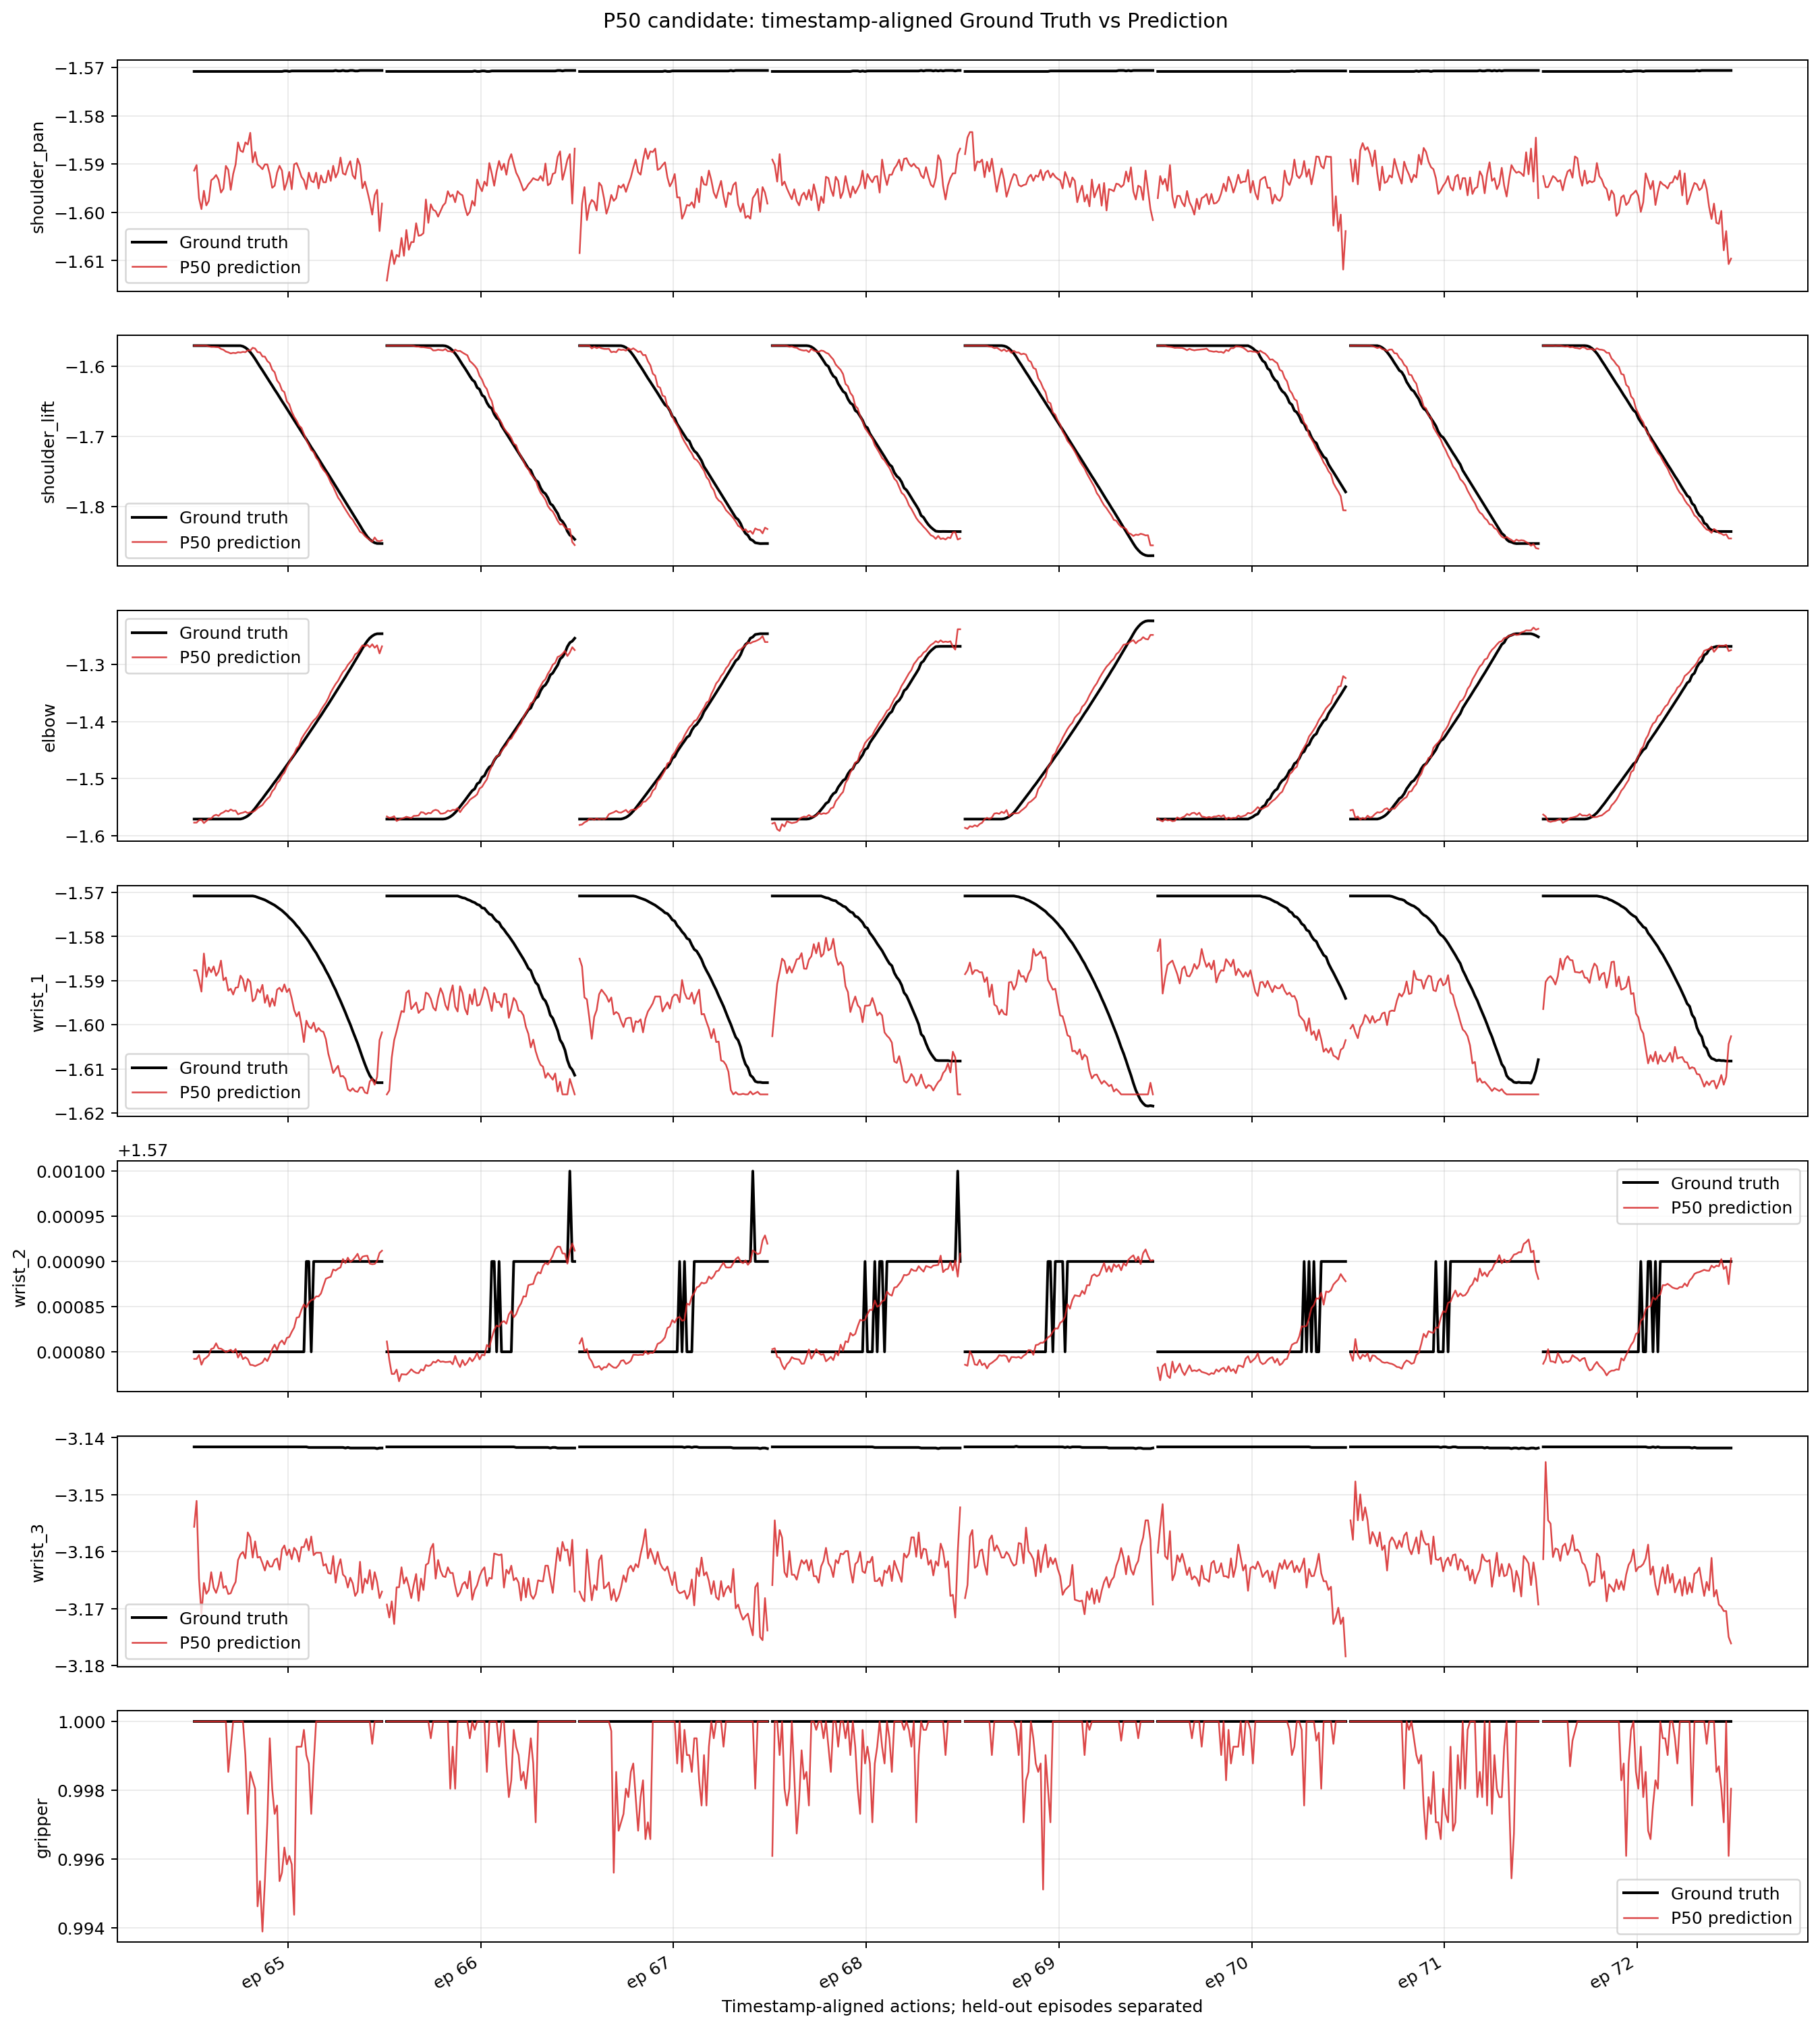

In [19]:

# Timestamp-aligned P50 Ground Truth vs Prediction visualization.
if RUN_EVALUATION:
    import csv
    import numpy as np
    import matplotlib.pyplot as plt
    from IPython.display import Image, display

    action_names = [
        "shoulder_pan", "shoulder_lift", "elbow", "wrist_1",
        "wrist_2", "wrist_3", "gripper",
    ]
    with np.load(EVAL_CKA / "actions.npz") as payload:
        prediction = np.asarray(payload["prediction"], dtype=np.float64)
        ground_truth = np.asarray(payload["ground_truth"], dtype=np.float64)
    with (EVAL_CKA / "per_step.csv").open("r", newline="", encoding="utf-8") as file:
        step_rows = list(csv.DictReader(file))

    pred_by_time, gt_by_time = {}, {}
    cursor = 0
    for row in step_rows:
        episode = int(row["trajectory_id"])
        start = int(row["step"])
        horizon = int(row["evaluated_horizon"])
        stop = cursor + horizon
        assert horizon > 0 and stop <= len(prediction)
        pred_by_time.setdefault(episode, {})
        gt_by_time.setdefault(episode, {})
        for offset in range(horizon):
            timestamp = start + offset
            pred_by_time[episode].setdefault(timestamp, []).append(prediction[cursor + offset])
            gt_by_time[episode].setdefault(timestamp, []).append(ground_truth[cursor + offset])
        cursor = stop
    assert cursor == len(prediction), (cursor, len(prediction))

    display_pred, display_gt = [], []
    aligned_pred, aligned_gt = [], []
    ticks, labels, position = [], [], 0
    for episode in sorted(pred_by_time):
        timestamps = sorted(pred_by_time[episode])
        episode_pred = np.stack([
            np.mean(pred_by_time[episode][timestamp], axis=0) for timestamp in timestamps
        ])
        episode_gt = np.stack([
            np.mean(gt_by_time[episode][timestamp], axis=0) for timestamp in timestamps
        ])
        aligned_pred.append(episode_pred)
        aligned_gt.append(episode_gt)
        display_pred.extend([episode_pred, np.full((1, prediction.shape[1]), np.nan)])
        display_gt.extend([episode_gt, np.full((1, prediction.shape[1]), np.nan)])
        ticks.append(position + max(len(episode_pred) - 1, 0) / 2)
        labels.append(f"ep {episode}")
        position += len(episode_pred) + 1

    aligned_pred = np.concatenate(aligned_pred)
    aligned_gt = np.concatenate(aligned_gt)
    plot_pred = np.concatenate(display_pred)
    plot_gt = np.concatenate(display_gt)
    x = np.arange(len(plot_pred))

    figure, axes = plt.subplots(7, 1, figsize=(15, 17), sharex=True)
    for dimension, axis in enumerate(axes):
        axis.plot(x, plot_gt[:, dimension], color="black", linewidth=1.6, label="Ground truth")
        axis.plot(x, plot_pred[:, dimension], color="#d62728", linewidth=1.0, alpha=0.85, label="P50 prediction")
        axis.set_ylabel(action_names[dimension])
        axis.grid(alpha=0.25)
        axis.legend(loc="best")
    axes[-1].set_xticks(ticks, labels, rotation=30, ha="right")
    axes[-1].set_xlabel("Timestamp-aligned actions; held-out episodes separated")
    figure.suptitle("P50 candidate: timestamp-aligned Ground Truth vs Prediction")
    figure.tight_layout(rect=(0, 0, 1, 0.985))
    plot_path = CANDIDATE_ANALYSIS / "aligned_prediction_vs_ground_truth_p50.png"
    figure.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.close(figure)

    error = aligned_pred - aligned_gt
    diagnostics = {
        "variant": "cka_p50_keep16dit_keep8lang",
        "method": "overlapping action chunks aligned by episode and absolute timestamp; predictions averaged only at identical timestamps",
        "aligned_points": int(len(aligned_pred)),
        "aligned_mse": float(np.mean(error ** 2)),
        "aligned_mae": float(np.mean(np.abs(error))),
        "plot": str(plot_path),
    }
    (CANDIDATE_ANALYSIS / "aligned_prediction_diagnostics.json").write_text(
        json.dumps(diagnostics, indent=2), encoding="utf-8"
    )
    print(json.dumps(diagnostics, indent=2))
    display(Image(filename=str(plot_path)))
else:
    print("Aligned P50 visualization runs only in WORKFLOW_PHASE='evaluate'.")


In [20]:

# Candidate-only repeated-seed first-action diagnostics. Metrics are never smoothed.
if RUN_EVALUATION:
    import csv
    import numpy as np
    import matplotlib.pyplot as plt

    action_names = [
        "shoulder_pan", "shoulder_lift", "elbow", "wrist_1",
        "wrist_2", "wrist_3", "gripper",
    ]

    def load_first_action_samples(eval_dir):
        eval_dir = Path(eval_dir)
        with np.load(eval_dir / "actions.npz") as payload:
            prediction = np.asarray(payload["prediction"], dtype=np.float64)
            ground_truth = np.asarray(payload["ground_truth"], dtype=np.float64)
        with (eval_dir / "per_step.csv").open("r", newline="", encoding="utf-8") as file:
            rows = list(csv.DictReader(file))
        keys, first_prediction, first_ground_truth = [], [], []
        cursor = 0
        for row in rows:
            horizon = int(row["evaluated_horizon"])
            assert horizon > 0 and cursor + horizon <= len(prediction)
            keys.append((int(row["trajectory_id"]), int(row["step"])))
            first_prediction.append(prediction[cursor])
            first_ground_truth.append(ground_truth[cursor])
            cursor += horizon
        assert cursor == len(prediction), (cursor, len(prediction))
        return keys, np.stack(first_prediction), np.stack(first_ground_truth)

    loaded = [load_first_action_samples(repeat_dir(seed)) for seed in EVAL_REPEAT_SEEDS]
    keys = loaded[0][0]
    ground_truth = loaded[0][2]
    for candidate_keys, _, candidate_gt in loaded[1:]:
        assert candidate_keys == keys
        assert np.allclose(candidate_gt, ground_truth, atol=1e-7, rtol=1e-7)
    predictions = np.stack([item[1] for item in loaded], axis=0)
    raw = predictions[0]
    mean = predictions.mean(axis=0)
    std = predictions.std(axis=0)
    raw_error = raw - ground_truth
    mean_error = mean - ground_truth

    summary = {
        "method": "first action per held-out timestamp; eight paired diffusion seeds; no smoothing",
        "variant": "cka_p50_keep16dit_keep8lang",
        "denoising_steps": DENOISING_STEPS,
        "seeds": EVAL_REPEAT_SEEDS,
        "raw_mse": float(np.mean(raw_error ** 2)),
        "raw_mae": float(np.mean(np.abs(raw_error))),
        "ensemble_mse": float(np.mean(mean_error ** 2)),
        "ensemble_mae": float(np.mean(np.abs(mean_error))),
        "sampling_std": float(np.mean(std)),
    }
    metric_rows = []
    for dimension, channel in enumerate(action_names):
        channel_raw_error = raw[:, dimension] - ground_truth[:, dimension]
        channel_mean_error = mean[:, dimension] - ground_truth[:, dimension]
        metric_rows.append({
            "model": "cka_p50_keep16dit_keep8lang",
            "dimension": dimension,
            "channel": channel,
            "raw_mse": float(np.mean(channel_raw_error ** 2)),
            "raw_mae": float(np.mean(np.abs(channel_raw_error))),
            "ensemble_mse": float(np.mean(channel_mean_error ** 2)),
            "ensemble_mae": float(np.mean(np.abs(channel_mean_error))),
            "mean_sampling_std": float(np.mean(std[:, dimension])),
        })

    figure, axes = plt.subplots(7, 1, figsize=(16, 17), sharex=True)
    x = np.arange(len(ground_truth))
    for dimension, axis in enumerate(axes):
        axis.plot(x, ground_truth[:, dimension], color="black", linewidth=1.7, label="ground truth")
        axis.plot(x, raw[:, dimension], color="#ff9896", linewidth=0.8, alpha=0.65, label="raw seed 42")
        axis.plot(x, mean[:, dimension], color="#d62728", linewidth=1.2, label="8-seed mean")
        axis.fill_between(
            x,
            mean[:, dimension] - std[:, dimension],
            mean[:, dimension] + std[:, dimension],
            color="#d62728",
            alpha=0.14,
            label="±1 sampling std",
        )
        axis.set_ylabel(action_names[dimension])
        axis.grid(alpha=0.2)
        axis.legend(loc="best", ncol=2)
    axes[-1].set_xlabel("First predicted action at each held-out timestamp")
    figure.suptitle("P50 candidate: raw and repeated-seed first-action prediction")
    figure.tight_layout(rect=(0, 0, 1, 0.985))
    plot_path = CANDIDATE_ANALYSIS / "first_action_diffusion_ensemble_p50.png"
    figure.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.close(figure)

    summary["plot"] = str(plot_path)
    summary_path = CANDIDATE_ANALYSIS / "ensemble_first_action_metrics.json"
    summary_path.write_text(json.dumps(summary, indent=2), encoding="utf-8")
    csv_path = CANDIDATE_ANALYSIS / "ensemble_first_action_per_channel.csv"
    with csv_path.open("w", newline="", encoding="utf-8") as file:
        writer = csv.DictWriter(file, fieldnames=list(metric_rows[0]))
        writer.writeheader()
        writer.writerows(metric_rows)
    print(json.dumps(summary, indent=2))
    print("Saved:", summary_path, csv_path)
else:
    print("Repeated-seed P50 diagnostics run only in WORKFLOW_PHASE='evaluate'.")


{
  "method": "first action per held-out timestamp; eight paired diffusion seeds; no smoothing",
  "variant": "cka_p50_keep16dit_keep8lang",
  "denoising_steps": 16,
  "seeds": [
    42,
    43,
    44,
    45,
    46,
    47,
    48,
    49
  ],
  "raw_mse": 0.0002517345529857321,
  "raw_mae": 0.011436986138245888,
  "ensemble_mse": 0.00021981638835559983,
  "ensemble_mae": 0.011219301776561354,
  "sampling_std": 0.005318869652434504,
  "plot": "/mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/candidate_analysis/first_action_diffusion_ensemble_p50.png"
}
Saved: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/candidate_analysis/ensemble_first_action_metrics.json /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/

## G. Original-source versus recovered-P50 representation heatmaps


In [15]:
# Hotfix: restore shared CKA capture arguments after kernel restart.
from pathlib import Path
import os
import shutil

required_names = [
    "TRAIN_DATASET",
    "EMBODIMENT_TAG",
    "CALIBRATION_TRAJECTORIES",
    "SAMPLES_PER_CALIBRATION_TRAJECTORY",
    "SAMPLE_STRIDE",
    "DENOISING_STEPS",
    "SEED",
    "CKA_OUTPUT",
    "SOURCE_CALIBRATION_DIR",
    "OUTPUT_ROOT",
    "HEATMAP_ROOT",
    "REPO_DIR",
    "RUN_ENV",
]

missing_names = [
    name for name in required_names
    if name not in globals()
]
assert not missing_names, (
    "Cần chạy lại các cell cấu hình/setup trước. "
    f"Biến còn thiếu: {missing_names}"
)

capture_common = [
    "--dataset-path", str(TRAIN_DATASET),
    "--embodiment-tag", EMBODIMENT_TAG,
    "--trajectory-ids",
    *map(str, CALIBRATION_TRAJECTORIES),
    "--samples-per-trajectory",
    str(SAMPLES_PER_CALIBRATION_TRAJECTORY),
    "--sample-stride", str(SAMPLE_STRIDE),
    "--denoising-steps", str(DENOISING_STEPS),
    "--seed", str(SEED),
    "--require-hf-token",
]

assert Path(CKA_OUTPUT).is_dir(), (
    f"Không tìm thấy recovered model: {CKA_OUTPUT}"
)

source_required = [
    Path(SOURCE_CALIBRATION_DIR) / "metadata.json",
    Path(SOURCE_CALIBRATION_DIR) / "activations.npz",
]
missing_source = [
    str(path) for path in source_required
    if not path.is_file() or path.stat().st_size == 0
]
assert not missing_source, (
    "Source calibration chưa hoàn chỉnh; cần chạy prepare_cka. "
    f"Thiếu: {missing_source}"
)

print("Heatmap hotfix ready.")
print("Recovered model:", CKA_OUTPUT)
print("Source calibration:", SOURCE_CALIBRATION_DIR)
print("Calibration trajectories:", CALIBRATION_TRAJECTORIES)
print("Samples per trajectory:", SAMPLES_PER_CALIBRATION_TRAJECTORY)

Heatmap hotfix ready.
Recovered model: /mnt/gr00t-experiment/training/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/cka_p50_standalone_full_recovery_l40s_6000steps
Source calibration: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/source_calibration
Calibration trajectories: [0, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40, 44, 48, 52, 56, 60]
Samples per trajectory: 16


In [17]:
if RUN_EVALUATION:
    recovered = OUTPUT_ROOT / "recovered_calibration"

    def calibration_complete(path):
        path = Path(path)
        return all(
            (path / name).is_file() and (path / name).stat().st_size > 0
            for name in ["metadata.json", "activations.npz"]
        )

    assert calibration_complete(SOURCE_CALIBRATION_DIR), (
        f"Missing/incomplete source CKA capture: {SOURCE_CALIBRATION_DIR}. "
        "Run WORKFLOW_PHASE='prepare_cka' first."
    )
    if calibration_complete(recovered):
        print("Reuse completed recovered activation capture:", recovered)
    else:
        if recovered.exists():
            assert recovered.parent.resolve() == OUTPUT_ROOT.resolve()
            shutil.rmtree(recovered)
        run_checked(
            "Capture recovered UR10e CKA activations",
            uv_python(
                "scripts/cka_n1d7/capture_activations.py",
                "--model-path", str(CKA_OUTPUT),
                "--output-dir", str(recovered),
                *capture_common,
            ),
            cwd=REPO_DIR, env=RUN_ENV,
        )
    assert calibration_complete(recovered), recovered

    heatmap_summary = HEATMAP_ROOT / "cka_before_after_summary.json"
    heatmap_complete = heatmap_summary.is_file() and bool(list(HEATMAP_ROOT.glob("*.png")))
    if heatmap_complete:
        print("Reuse completed source/recovered heatmaps:", HEATMAP_ROOT)
    else:
        if HEATMAP_ROOT.exists():
            assert HEATMAP_ROOT.parent.resolve() == OUTPUT_ROOT.resolve()
            shutil.rmtree(HEATMAP_ROOT)
        HEATMAP_ROOT.mkdir(parents=True, exist_ok=True)
        run_checked(
            "Compare UR10e source and recovered heatmaps",
            uv_python(
                "scripts/cka_n1d7/compare_cka_heatmaps.py",
                "--baseline-calibration-dir", str(SOURCE_CALIBRATION_DIR),
                "--optimized-calibration-dir", str(recovered),
                "--output-dir", str(HEATMAP_ROOT),
            ),
            cwd=REPO_DIR, env=RUN_ENV,
        )
    assert heatmap_summary.is_file(), heatmap_summary
    assert list(HEATMAP_ROOT.glob("*.png")), HEATMAP_ROOT
    print("Heatmaps:", HEATMAP_ROOT)


[run] Capture recovered UR10e CKA activations started; status: /mnt/gr00t-experiment/experiments/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/results/runtime_status.json
/root/gr00t-runtime/Isaac-GR00T/gr00t/model/modules/dit.py:334: FutureWarning: Accessing config attribute `compute_dtype` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'compute_dtype' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.compute_dtype'.
/root/gr00t-runtime/Isaac-GR00T/gr00t/model/modules/dit.py:365: FutureWarning: Accessing config attribute `output_dim` directly via 'AlternateVLDiT' object attribute is deprecated. Please access 'output_dim' over 'AlternateVLDiT's config object instead, e.g. 'unet.config.output_dim'.
Total number of DiT parameters:  1091722240
Total number of SelfAttentionTransformer parameters:  201433088
Loading checkpoint shards: 100%|█████████████████████████████████████████████████| 2/2 [

In [ ]:
# Upload the complete recovered P50 folder to Hugging Face Hub.
# Includes model weights, checkpoints, optimizer/scheduler state, processor and configs.
from getpass import getpass
from pathlib import Path
import os

from huggingface_hub import HfApi

HF_REPO_ID = "Luke99662244/checkpoint2"
UPLOAD_FOLDER = Path(CKA_OUTPUT)

assert UPLOAD_FOLDER.is_dir(), f"Missing recovery folder: {UPLOAD_FOLDER}"

upload_files = [
    path
    for path in UPLOAD_FOLDER.rglob("*")
    if path.is_file()
]

assert upload_files, f"Recovery folder is empty: {UPLOAD_FOLDER}"

assert not list(UPLOAD_FOLDER.rglob("*.incomplete")), (
    f"Incomplete files exist under {UPLOAD_FOLDER}; "
    "finish recovery before upload."
)

token = os.environ.get("HF_TOKEN", "").strip()
if not token:
    token = getpass("Hugging Face write token: ").strip()

assert token, "A Hugging Face write token is required."

os.environ["HF_XET_HIGH_PERFORMANCE"] = "1"

api = HfApi(token=token)

api.create_repo(
    repo_id=HF_REPO_ID,
    repo_type="model",
    exist_ok=True,
)

total_bytes = sum(path.stat().st_size for path in upload_files)

print({
    "repo": f"https://huggingface.co/{HF_REPO_ID}",
    "source": str(UPLOAD_FOLDER),
    "files": len(upload_files),
    "size_gib": round(total_bytes / 1024**3, 3),
})

api.upload_large_folder(
    repo_id=HF_REPO_ID,
    repo_type="model",
    folder_path=str(UPLOAD_FOLDER),
)

print(f"Upload complete: https://huggingface.co/{HF_REPO_ID}")

## H. Offline evidence report and compact archive


In [25]:

if RUN_REPORT:
    from zipfile import ZIP_DEFLATED, ZipFile
    import hashlib

    required = [
        PRUNING_MANIFEST,
        OUTPUT_ROOT / "recovery_contract.json",
        EVAL_CKA / "summary.json",
        EVAL_CKA / "per_step.csv",
        CANDIDATE_ANALYSIS / "per_dimension_metrics.csv",
        CANDIDATE_ANALYSIS / "aligned_prediction_diagnostics.json",
        CANDIDATE_ANALYSIS / "ensemble_first_action_metrics.json",
        CANDIDATE_ANALYSIS / "ensemble_first_action_per_channel.csv",
        CANDIDATE_ANALYSIS / "control_latency.json",
        CANDIDATE_ANALYSIS / "aligned_prediction_vs_ground_truth_p50.png",
        CANDIDATE_ANALYSIS / "per_dimension_metrics.png",
        OUTPUT_ROOT / "diffusion_repeat_manifest.json",
        HEATMAP_ROOT / "cka_before_after_summary.json",
        TRAIN_OUTPUT_ROOT / f"{CKA_OUTPUT.name}_recovery_identity.json",
    ]
    missing = [str(path) for path in required if not path.exists()]
    assert not missing, f"Missing required P50 candidate evidence: {missing}"
    assert list(HEATMAP_ROOT.glob("*.png")), HEATMAP_ROOT
    assert root_model_ready(CKA_OUTPUT)
    assert latest_step(CKA_OUTPUT) >= FINAL_RECOVERY_STEP

    manifest = json.loads(PRUNING_MANIFEST.read_text(encoding="utf-8"))
    kept = {
        name: len(spec["keep_indices"])
        for name, spec in manifest["modules"].items()
    }
    assert kept == EXPECTED_KEPT_DEPTHS, (kept, EXPECTED_KEPT_DEPTHS)
    candidate_summary = json.loads((EVAL_CKA / "summary.json").read_text(encoding="utf-8"))
    ensemble = json.loads(
        (CANDIDATE_ANALYSIS / "ensemble_first_action_metrics.json").read_text(encoding="utf-8")
    )
    report = {
        "status": "candidate_only_offline_complete",
        "task": "UR10e + Robotiq cup pickup",
        "variant": "P50 standalone candidate-only full retained-module recovery",
        "resource_profile": "Modal 1x L40S, 8 CPU, 48 GiB RAM",
        "source_checkpoint": str(MODEL_PATH),
        "source_checkpoint_is_task_adapted": False,
        "external_reference_required_for_comparison": True,
        "data_split": {
            "train": TRAIN_EPISODES,
            "validation": VALIDATION_EPISODES,
            "test": TEST_EPISODES,
        },
        "candidate_step": latest_step(CKA_OUTPUT),
        "pruning_ratios": {
            "backbone_language": BACKBONE_LANGUAGE_PRUNE_RATIO,
            "action_dit": ACTION_DIT_PRUNE_RATIO,
            "vl_self_attention": VL_SELF_ATTENTION_PRUNE_RATIO,
        },
        "kept_depths": kept,
        "candidate": candidate_summary,
        "diffusion_first_action_diagnostics": ensemble,
        "claim_boundary": (
            "This archive contains P50 candidate-only offline evidence. It does not "
            "contain or recompute a baseline and contains no simulator/real-robot SR."
        ),
        "model_weights_in_zip": False,
        "candidate_model_path": str(CKA_OUTPUT),
    }
    (OUTPUT_ROOT / "final_offline_summary.json").write_text(
        json.dumps(report, indent=2), encoding="utf-8"
    )

    if FINAL_ZIP.exists():
        FINAL_ZIP.unlink()
    with ZipFile(FINAL_ZIP, "w", compression=ZIP_DEFLATED, allowZip64=True) as archive:
        for path in sorted(OUTPUT_ROOT.rglob("*")):
            if not path.is_file():
                continue
            if path.name in {"activations.npz", "actions.npz"} or path.suffix == ".mp4":
                continue
            archive.write(path, arcname=path.relative_to(EXPERIMENT_ROOT))
        recovery_identity_path = TRAIN_OUTPUT_ROOT / f"{CKA_OUTPUT.name}_recovery_identity.json"
        archive.write(
            recovery_identity_path,
            arcname=Path("results") / "recovery_identity.json",
        )
    digest = hashlib.sha256(FINAL_ZIP.read_bytes()).hexdigest()
    checksum = FINAL_ZIP.with_suffix(".zip.sha256")
    checksum.write_text(f"{digest}  {FINAL_ZIP.name}\n", encoding="utf-8")
    print("P50 candidate-only result ZIP:", FINAL_ZIP)
    print("Size MiB:", round(FINAL_ZIP.stat().st_size / 1024**2, 2))
    print("SHA-256:", digest)
    print("Candidate weights remain on Volume:", CKA_OUTPUT)
else:
    print("Set WORKFLOW_PHASE='report' after P50 evaluation and heatmaps complete.")


P50 candidate-only result ZIP: /mnt/gr00t-experiment/archives/ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps_candidate_only_results.zip
Size MiB: 8.9
SHA-256: 428c35005ce6109a347ebb2ca3db6d3608c67a095a918efe2d882a2c27833a9d
Candidate weights remain on Volume: /mnt/gr00t-experiment/training/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/cka_p50_standalone_full_recovery_l40s_6000steps


## Download from Modal Volume

Run the final cell to validate SHA-256 and print exact `modal volume get` commands.
The Modal web frontend is not used for large archives.


In [ ]:
if RUN_REPORT:
    from pathlib import Path
    import hashlib


    def sha256_file(path, chunk_size=8 * 1024 * 1024):
        digest = hashlib.sha256()
        with Path(path).open("rb") as file:
            while chunk := file.read(chunk_size):
                digest.update(chunk)
        return digest.hexdigest()


    archive = Path(FINAL_ZIP)
    checksum = archive.with_suffix(".zip.sha256")
    assert archive.exists(), f"Missing archive: {archive}. Run WORKFLOW_PHASE='report'."
    assert checksum.exists(), checksum
    expected = checksum.read_text(encoding="utf-8").split()[0]
    actual = sha256_file(archive)
    assert actual == expected, (actual, expected)
    remote_archive = archive.relative_to(PERSIST_ROOT).as_posix()
    remote_checksum = checksum.relative_to(PERSIST_ROOT).as_posix()
    print("READY:", archive)
    print("Size MiB:", round(archive.stat().st_size / 1024**2, 2))
    print("SHA-256:", actual)
    print("Run locally after `pip install modal` and `modal setup`:")
    print(f'modal volume get {MODAL_VOLUME_NAME} "{remote_archive}" "./{archive.name}"')
    print(f'modal volume get {MODAL_VOLUME_NAME} "{remote_checksum}" "./{checksum.name}"')

else:
    print("Archive download validation skipped until WORKFLOW_PHASE='report'.")


In [26]:
# Create a downloadable ZIP of the complete recovered P50 directory.
# Uses ZIP_STORED because safetensors/optimizer files are already difficult
# to compress; this is substantially faster and avoids unnecessary CPU load.

from pathlib import Path
from zipfile import ZIP_STORED, ZipFile
import hashlib
import json
import os
import shutil
import time

SOURCE_DIR = Path(
    "/mnt/gr00t-experiment/training/"
    "gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_"
    "keep4vlsa_full_l40s_standalone_candidate_6000steps/"
    "cka_p50_standalone_full_recovery_l40s_6000steps"
)

ARCHIVE_DIR = Path("/mnt/gr00t-experiment/archives/full_p50_checkpoint")
ZIP_PATH = ARCHIVE_DIR / (
    "cka_p50_standalone_full_recovery_l40s_6000steps.zip"
)
PARTIAL_PATH = ZIP_PATH.with_suffix(".zip.partial")
CHECKSUM_PATH = ZIP_PATH.with_suffix(".zip.sha256")
MANIFEST_PATH = ZIP_PATH.with_suffix(".zip.manifest.json")

assert SOURCE_DIR.is_dir(), f"Source directory not found: {SOURCE_DIR}"

files = sorted(
    path for path in SOURCE_DIR.rglob("*")
    if path.is_file()
)
directories = sorted(
    path for path in SOURCE_DIR.rglob("*")
    if path.is_dir()
)

assert files, f"No files found under: {SOURCE_DIR}"

incomplete_files = list(SOURCE_DIR.rglob("*.incomplete"))
assert not incomplete_files, (
    "Source contains incomplete files: "
    + ", ".join(map(str, incomplete_files[:10]))
)

total_bytes = sum(path.stat().st_size for path in files)

ARCHIVE_DIR.mkdir(parents=True, exist_ok=True)

free_bytes = shutil.disk_usage(ARCHIVE_DIR).free
required_bytes = total_bytes + 1024**3  # 1 GiB safety margin

print("Source:", SOURCE_DIR)
print("Files:", len(files))
print("Directories:", len(directories))
print("Source size GiB:", round(total_bytes / 1024**3, 3))
print("Free space GiB:", round(free_bytes / 1024**3, 3))
print("Destination:", ZIP_PATH)

assert free_bytes >= required_bytes, (
    "Insufficient free space on the Modal Volume. "
    f"Required approximately {required_bytes / 1024**3:.2f} GiB, "
    f"available {free_bytes / 1024**3:.2f} GiB."
)

# Reuse an already completed archive instead of recreating it.
if ZIP_PATH.is_file() and ZIP_PATH.stat().st_size > 0:
    print("Existing ZIP detected; creation skipped:", ZIP_PATH)

else:
    # Remove only a partial archive left by an interrupted earlier attempt.
    if PARTIAL_PATH.exists():
        PARTIAL_PATH.unlink()
        print("Removed interrupted partial archive:", PARTIAL_PATH)

    started = time.time()

    with ZipFile(
        PARTIAL_PATH,
        mode="w",
        compression=ZIP_STORED,
        allowZip64=True,
    ) as archive:

        # Preserve empty directories as well.
        for directory in directories:
            if not any(directory.iterdir()):
                relative = directory.relative_to(SOURCE_DIR)
                archive.writestr(
                    (Path(SOURCE_DIR.name) / relative).as_posix() + "/",
                    "",
                )

        for index, path in enumerate(files, start=1):
            relative = path.relative_to(SOURCE_DIR)
            archive_name = Path(SOURCE_DIR.name) / relative
            archive.write(path, arcname=archive_name.as_posix())

            if index == 1 or index % 25 == 0 or index == len(files):
                print(
                    f"[{index}/{len(files)}] "
                    f"{relative.as_posix()}"
                )

    os.replace(PARTIAL_PATH, ZIP_PATH)

    print(
        "ZIP creation completed in minutes:",
        round((time.time() - started) / 60, 2),
    )

# Verify that the ZIP contains the expected number and total size of files.
with ZipFile(ZIP_PATH, "r") as archive:
    archived_files = [
        info for info in archive.infolist()
        if not info.is_dir()
    ]
    archived_bytes = sum(info.file_size for info in archived_files)

assert len(archived_files) == len(files), (
    len(archived_files),
    len(files),
)
assert archived_bytes == total_bytes, (
    archived_bytes,
    total_bytes,
)

# Calculate SHA-256 without loading the large ZIP into RAM.
digest = hashlib.sha256()
with ZIP_PATH.open("rb") as handle:
    while chunk := handle.read(16 * 1024 * 1024):
        digest.update(chunk)

sha256 = digest.hexdigest()

CHECKSUM_PATH.write_text(
    f"{sha256}  {ZIP_PATH.name}\n",
    encoding="utf-8",
)

manifest = {
    "source": str(SOURCE_DIR),
    "archive": str(ZIP_PATH),
    "archive_size_bytes": ZIP_PATH.stat().st_size,
    "source_file_count": len(files),
    "source_directory_count": len(directories),
    "source_total_bytes": total_bytes,
    "archived_file_count": len(archived_files),
    "archived_total_bytes": archived_bytes,
    "compression": "ZIP_STORED",
    "sha256": sha256,
}

MANIFEST_PATH.write_text(
    json.dumps(manifest, indent=2),
    encoding="utf-8",
)

print("\n===== ARCHIVE READY =====")
print(json.dumps(manifest, indent=2))

remote_zip = ZIP_PATH.relative_to(
    Path("/mnt/gr00t-experiment")
).as_posix()

remote_checksum = CHECKSUM_PATH.relative_to(
    Path("/mnt/gr00t-experiment")
).as_posix()

print("\nChạy trên máy cá nhân:")
print(
    f'modal volume get gr00t-ur10e-cup '
    f'"{remote_zip}" "./{ZIP_PATH.name}"'
)
print(
    f'modal volume get gr00t-ur10e-cup '
    f'"{remote_checksum}" "./{CHECKSUM_PATH.name}"'
)

Source: /mnt/gr00t-experiment/training/gr00t_n1d7_ur10e_cup_cka_p50_keep16dit_keep8lang_keep4vlsa_full_l40s_standalone_candidate_6000steps/cka_p50_standalone_full_recovery_l40s_6000steps
Files: 107
Directories: 12
Source size GiB: 24.445
Free space GiB: 381.47
Destination: /mnt/gr00t-experiment/archives/full_p50_checkpoint/cka_p50_standalone_full_recovery_l40s_6000steps.zip
[1/107] .cache/huggingface/.gitignore
[25/107] .cache/huggingface/upload/checkpoint-6000/processor_config.json.lock
[50/107] .cache/huggingface/upload/experiment_cfg/final_model_config.json.metadata
[75/107] checkpoint-6000/experiment_cfg/conf.yaml
[100/107] model.safetensors.index.json
[107/107] wandb_config.json
ZIP creation completed in minutes: 9.12
